# 深大微堆同心圆孔位与三维几何模型构建

本Notebook在已完成的材料Notebook基础上，按统一文献参考计算情景逐步建立MNSR-SZ三维几何。中央控制棒导管和第8圈4根连接杆位置固定，345根燃料元件与5根假元件数量固定；后续优化真正改变的变量仅是5个假元件在350个普通孔位中的编号。当前模型是有限高度的三维简化参考模型，不是完整工程图纸复现模型。

## 1 运行环境与材料对象

先确认Notebook实际使用的Python和OpenMC环境，再通过相对路径运行已经验证的材料Notebook。几何Notebook直接使用其中生成的`materials`和`material_map`，但不会从`geometry.py`导入模型。

In [1]:
import sys
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openmc
from IPython import get_ipython
from IPython.display import display

plt.rcParams["font.sans-serif"] = ["WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("Python解释器：", sys.executable)
print("OpenMC版本：", openmc.__version__)
print("OpenMC安装位置：", openmc.__file__)

Python解释器： ~/miniconda3/bin/python
OpenMC版本： 0.15.3.dev146+gc0f302db6
OpenMC安装位置： ~/.local/lib/python3.13/site-packages/openmc/__init__.py


In [2]:
material_notebook_path = Path("MNSR_materials_development.ipynb")

try:
    get_ipython().run_line_magic("run", str(material_notebook_path))
except ModuleNotFoundError as error:
    if error.name != "nbformat":
        raise

    # 当前环境未安装nbformat时，直接在同一内核逐格执行Notebook源码。
    import json

    material_notebook = json.loads(
        material_notebook_path.read_text(encoding="utf-8")
    )
    for cell in material_notebook["cells"]:
        if cell["cell_type"] != "code":
            continue
        execution_result = get_ipython().run_cell(
            "".join(cell["source"])
        )
        if execution_result.error_before_exec is not None:
            raise execution_result.error_before_exec
        if execution_result.error_in_exec is not None:
            raise execution_result.error_in_exec

required_material_keys = {
    "fuel",
    "fuel_clad",
    "dummy",
    "tie_rod",
    "control_rod_clad",
    "control_rod_inner",
    "guide_tube",
    "vessel",
    "water",
    "beryllium",
    "cadmium",
}

assert "materials" in globals()
assert "material_map" in globals()
assert required_material_keys.issubset(material_map)

print("材料对象加载成功。")

Python解释器: ~/miniconda3/bin/python
OpenMC版本: 0.15.3.dev146+gc0f302db6
OpenMC安装位置: ~/.local/lib/python3.13/site-packages/openmc/__init__.py
使用的核数据库： ~/openmc_data/endfb-vii.1-hdf5/cross_sections.xml
找到的cross_sections.xml候选文件：
0 ~/openmc_data/endfb-vii.1-hdf5/cross_sections.xml
铀同位素原子份额：
U234: 0.002030905779
U235: 0.126389969504
U236: 0.002517072902
U238: 0.869062051815
铀原子份额之和： 1.0
U:O原子数比：1: 2.0
反算U-235铀内质量百分比： 12.499999999999998
燃料定义阶段捕获的警告： []
Zircaloy-4归一化质量份额： {'Zr': 0.9793000000000001, 'Sn': 0.017, 'Fe': 0.0024, 'Cr': 0.0013}
Al-303-1归一化质量份额： {'Al': 0.9777825791653787, 'Fe': 0.012003469002541733, 'Si': 0.010002890835451445, 'Cu': 5.0014454177257224e-05, 'Zn': 3.0008672506354334e-05, 'Mn': 3.0008672506354334e-05, 'Mg': 5.0014454177257224e-05, 'Ti': 5.0014454177257224e-05, 'B': 1.0002890835451446e-06}
LT-21归一化质量份额： {'Al': 0.981648, 'Si': 0.009000000000000001, 'Mg': 0.006750000000000001, 'Fe': 0.002, 'Ni': 0.0003, 'Cu': 0.0001, 'Mn': 0.0001, 'Ti': 0.0001, 'Cd': 1e-06, 'B': 1e-06}
SS-

## 2 几何参数与模型版本

孔位、燃料尺寸、栅距和参考假元件编号保持不变。

Notebook前半段继续保留原来所有构件统一23 cm、容器外壁直接真空的`legacy_simplified`教学基线。参数化接口默认构建`iaea_reference`，补入有限高度侧铍、底铍、独立导管高度和容器外计算池水。

这些修正依据IAEA-TECDOC-1844给出的主要尺寸建立，不通过改变富集度、燃料密度、燃料数量或孔位来调节`keff`。

In [ ]:
# 同心圆孔位
PITCH = 1.095
RING_DISTRIBUTION = [
    1, 6, 12, 19, 26, 32,
    39, 45, 52, 58, 65,
]

# 低浓铀燃料元件与铝合金假元件（保持不变）
R_FUEL_MEAT = 0.215
R_FUEL_CLAD = 0.275
R_DUMMY = 0.275
R_TIE_ROD = 0.215

# 中央控制棒导管与插入状态控制棒（径向尺寸保持不变）
R_GUIDE_INNER = 0.45
R_GUIDE_OUTER = 0.60
R_CONTROL_INNER_AL = 0.095
R_CADMIUM_OUTER = 0.195
R_SS304_INNER = 0.20
R_SS304_OUTER = 0.25

# 原简化模型和IAEA参考模型共用的径向结构
R_CORE = 11.50
R_BE_INNER = 11.55
R_BE_OUTER = 21.75
R_VESSEL_INNER = 30.00
R_VESSEL_OUTER = 31.00

# legacy_simplified：所有构件统一23 cm并在容器外壁设真空。
MODEL_HEIGHT = 23.0
Z_BOTTOM = -MODEL_HEIGHT / 2
Z_TOP = MODEL_HEIGHT / 2

# iaea_reference：燃料有效区
ACTIVE_FUEL_HEIGHT = 23.0
Z_FUEL_BOTTOM = -11.5
Z_FUEL_TOP = 11.5

# iaea_reference：侧铍
R_SIDE_BE_INNER = 11.55
R_SIDE_BE_OUTER = 21.75
SIDE_BE_HEIGHT = 23.85
Z_SIDE_BE_BOTTOM = -SIDE_BE_HEIGHT / 2
Z_SIDE_BE_TOP = SIDE_BE_HEIGHT / 2

# iaea_reference：底铍及其中央水孔
BOTTOM_BE_RADIUS = 14.5
BOTTOM_BE_HOLE_RADIUS = 1.0
BOTTOM_BE_THICKNESS = 5.0
BOTTOM_TO_SIDE_GAP = 0.6
Z_BOTTOM_BE_TOP = Z_SIDE_BE_BOTTOM - BOTTOM_TO_SIDE_GAP
Z_BOTTOM_BE_BOTTOM = Z_BOTTOM_BE_TOP - BOTTOM_BE_THICKNESS

# 初始装料默认无顶部铍；非零值仅用于敏感性分析。
INITIAL_TOP_BE_THICKNESS = 0.0
MAX_TOP_BE_THICKNESS = 10.95
TOP_BE_RADIUS = 12.15
TOP_BE_HOLE_RADIUS = 1.0
TOP_TO_SIDE_GAP = 0.75

# 控制棒导管与可移动控制棒组件的文献长度
GUIDE_TUBE_HEIGHT = 25.8
Z_GUIDE_BOTTOM = -GUIDE_TUBE_HEIGHT / 2
Z_GUIDE_TOP = GUIDE_TUBE_HEIGHT / 2
CD_ABSORBER_HEIGHT = 26.6
CONTROL_AL_ROD_HEIGHT = 29.0
CONTROL_SS_TUBE_HEIGHT = 45.0

# IAEA-TECDOC-1844给出了尺寸和0–24 cm位置曲线，但未公开给出
# fully inserted时Cd两端相对堆芯中心的绝对z坐标。本文显式采用对称假设：
# position=0 cm时，26.6 cm Cd吸收段关于z=0对称；正位置表示向+z拔出。
CONTROL_ROD_FULLY_INSERTED_REFERENCE_CM = 0.0
CONTROL_ROD_MAX_PILOT_WITHDRAWAL_CM = 24.0
CONTROL_ROD_AXIAL_MODEL_ASSUMPTION = (
    "Public IAEA dimensions do not define the as-built absolute z position. "
    "At position=0 cm, the 26.6 cm Cd absorber is centred at core z=0; "
    "Cd, central Al rod and SS tube translate together toward +z on withdrawal."
)

# 容器外计算池水截断距离；不是实际池体精确尺寸。
POOL_RADIAL_MARGIN = 50.0
POOL_AXIAL_MARGIN_TOP = 50.0
POOL_AXIAL_MARGIN_BOTTOM = 50.0
R_POOL_BOUNDARY = R_VESSEL_OUTER + POOL_RADIAL_MARGIN
Z_POOL_BOTTOM = Z_BOTTOM_BE_BOTTOM - POOL_AXIAL_MARGIN_BOTTOM
Z_POOL_TOP = max(Z_SIDE_BE_TOP, Z_FUEL_TOP) + POOL_AXIAL_MARGIN_TOP

print("legacy_simplified轴向范围：", Z_BOTTOM, "cm 到", Z_TOP, "cm")
print("IAEA燃料有效区：", Z_FUEL_BOTTOM, "cm 到", Z_FUEL_TOP, "cm")
print("IAEA侧铍范围：", Z_SIDE_BE_BOTTOM, "cm 到", Z_SIDE_BE_TOP, "cm")
print("IAEA底铍范围：", Z_BOTTOM_BE_BOTTOM, "cm 到", Z_BOTTOM_BE_TOP, "cm")
print("计算池水边界：R =", R_POOL_BOUNDARY, "cm；z =", Z_POOL_BOTTOM, "到", Z_POOL_TOP, "cm")

In [4]:
assert sum(RING_DISTRIBUTION) == 355
assert R_FUEL_MEAT < R_FUEL_CLAD
assert R_CONTROL_INNER_AL < R_CADMIUM_OUTER
assert R_CADMIUM_OUTER < R_SS304_INNER
assert R_SS304_INNER < R_SS304_OUTER
assert R_SS304_OUTER < R_GUIDE_INNER
assert R_GUIDE_INNER < R_GUIDE_OUTER
assert Z_BOTTOM < Z_TOP

print("统一几何尺寸检查通过。")

统一几何尺寸检查通过。


## 3 各圈初始方位角

`RING_OFFSETS`控制每一圈第一个孔位的起始方位角。统一参考模型暂全部设为0；假元件优化不改变孔位坐标或圈层相位。如果未来获得更准确资料，只需修改此列表。

In [5]:
RING_OFFSETS = [0.0] * len(RING_DISTRIBUTION)

assert len(RING_OFFSETS) == len(RING_DISTRIBUTION)
print("各圈初始方位角（rad）：", RING_OFFSETS)

各圈初始方位角（rad）： [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


## 4 同心圆物理位置生成

下面直接用两层循环生成11圈共355个物理位置。位置由圈号和圈内编号唯一决定，坐标在后续所有候选方案中保持不变；优化只改变普通孔位所填充的元件类型。

In [6]:
physical_position_records = []
physical_position_id = 0

for ring_index, number_of_positions in enumerate(RING_DISTRIBUTION):
    ring_radius_cm = ring_index * PITCH

    for local_index in range(number_of_positions):
        theta_rad = (
            RING_OFFSETS[ring_index]
            + 2 * math.pi * local_index / number_of_positions
        )
        x_cm = ring_radius_cm * math.cos(theta_rad)
        y_cm = ring_radius_cm * math.sin(theta_rad)

        if ring_index == 0:
            x_cm = 0.0
            y_cm = 0.0

        physical_position_records.append({
            "physical_position_id": physical_position_id,
            "ring_index": ring_index,
            "local_index": local_index,
            "ring_radius_cm": ring_radius_cm,
            "theta_rad": theta_rad,
            "theta_deg": math.degrees(theta_rad),
            "x_cm": x_cm,
            "y_cm": y_cm,
        })
        physical_position_id += 1

physical_positions_df = pd.DataFrame(physical_position_records)
display(physical_positions_df.head(8))
print("物理位置总数：", len(physical_positions_df))

assert len(physical_positions_df) == 355
assert not physical_positions_df.duplicated(
    subset=["ring_index", "local_index"]
).any()

,physical_position_id,ring_index,local_index,ring_radius_cm,theta_rad,theta_deg,x_cm,y_cm
0,0,0,0,0.000,0.000000,0.0,0.0000,0.000000e+00
1,1,1,0,1.095,0.000000,0.0,1.0950,0.000000e+00
2,2,1,1,1.095,1.047198,60.0,0.5475,9.482978e-01
3,3,1,2,1.095,2.094395,120.0,-0.5475,9.482978e-01
4,4,1,3,1.095,3.141593,180.0,-1.0950,1.340988e-16
5,5,1,4,1.095,4.188790,240.0,-0.5475,-9.482978e-01
6,6,1,5,1.095,5.235988,300.0,0.5475,-9.482978e-01
7,7,2,0,2.190,0.000000,0.0,2.1900,0.000000e+00


物理位置总数： 355


## 5 中央位置与固定连接杆位置

第0圈中央位置固定为控制棒导管。第8圈共有52个位置，每隔13个位置放置一根连接杆，因此4根连接杆均匀分布。中央位置与连接杆都排除在假元件优化空间之外。

In [7]:
CENTRAL_POSITION = (0, 0)
TIE_ROD_RING_LOCAL = {
    (8, 0),
    (8, 13),
    (8, 26),
    (8, 39),
}

position_categories = []
for row in physical_positions_df.itertuples(index=False):
    ring_local = (row.ring_index, row.local_index)
    if ring_local == CENTRAL_POSITION:
        category = "central"
    elif ring_local in TIE_ROD_RING_LOCAL:
        category = "tie_rod"
    else:
        category = "ordinary"
    position_categories.append(category)

physical_positions_df["position_category"] = position_categories
category_counts = physical_positions_df["position_category"].value_counts()

assert category_counts["central"] == 1
assert category_counts["tie_rod"] == 4
assert category_counts["ordinary"] == 350

print(category_counts)

position_category
ordinary    350
tie_rod       4
central       1
Name: count, dtype: int64


## 6 普通孔位编号与优化空间

只对普通孔位按`ring_index`、`local_index`顺序编号为0到349。后续优化算法只操作这一编号，因此不会误选中央导管或连接杆；每个普通编号在所有候选排布中保持稳定。

In [8]:
ordinary_positions_df = (
    physical_positions_df.loc[
        physical_positions_df["position_category"] == "ordinary"
    ]
    .sort_values(["ring_index", "local_index"])
    .reset_index(drop=True)
    .copy()
)
ordinary_positions_df.insert(
    0,
    "ordinary_position_id",
    range(len(ordinary_positions_df)),
)

ordinary_id_by_ring_local = {
    (int(row.ring_index), int(row.local_index)):
    int(row.ordinary_position_id)
    for row in ordinary_positions_df.itertuples(index=False)
}
ring_local_by_ordinary_id = {
    ordinary_id: ring_local
    for ring_local, ordinary_id in ordinary_id_by_ring_local.items()
}

assert len(ordinary_positions_df) == 350
assert ordinary_positions_df["ordinary_position_id"].tolist() == list(range(350))
assert all(
    ordinary_id_by_ring_local[ring_local_by_ordinary_id[position_id]]
    == position_id
    for position_id in range(350)
)

display(ordinary_positions_df.head(5))
display(ordinary_positions_df.tail(5))

,ordinary_position_id,physical_position_id,ring_index,local_index,ring_radius_cm,theta_rad,theta_deg,x_cm,y_cm,position_category
0,0,1,1,0,1.095,0.000000,0.0,1.0950,0.000000e+00,ordinary
1,1,2,1,1,1.095,1.047198,60.0,0.5475,9.482978e-01,ordinary
2,2,3,1,2,1.095,2.094395,120.0,-0.5475,9.482978e-01,ordinary
3,3,4,1,3,1.095,3.141593,180.0,-1.0950,1.340988e-16,ordinary
4,4,5,1,4,1.095,4.188790,240.0,-0.5475,-9.482978e-01,ordinary


,ordinary_position_id,physical_position_id,ring_index,local_index,ring_radius_cm,theta_rad,theta_deg,x_cm,y_cm,position_category
345,345,350,10,60,10.95,5.799863,332.307692,9.695743,-5.088719,ordinary
346,346,351,10,61,10.95,5.896528,337.846154,10.141612,-4.129189,ordinary
347,347,352,10,62,10.95,5.993192,343.384615,10.492792,-3.131105,ordinary
348,348,353,10,63,10.95,6.089857,348.923077,10.746003,-2.103788,ordinary
349,349,354,10,64,10.95,6.186521,354.461538,10.898881,-1.056827,ordinary


## 7 假元件参考排布

下面是用户后续最常修改的排布变量，也是优化问题中真正的控制变量：5个`ordinary_position_id`。统一参考方案将5根假元件均匀放在第10圈，用于和后续候选方案比较；这并不声称是已由完整工程资料核实的历史精确位置。

In [9]:
REFERENCE_DUMMY_RING_LOCAL = {
    (10, 0),
    (10, 13),
    (10, 26),
    (10, 39),
    (10, 52),
}

dummy_position_ids = {
    ordinary_id_by_ring_local[position]
    for position in REFERENCE_DUMMY_RING_LOCAL
}
all_ordinary_ids = set(range(350))
fuel_position_ids = all_ordinary_ids - dummy_position_ids

assert len(dummy_position_ids) == 5
assert all(0 <= position_id <= 349 for position_id in dummy_position_ids)
assert len(fuel_position_ids) == 345
assert fuel_position_ids.isdisjoint(dummy_position_ids)

ordinary_positions_df["component_type"] = np.where(
    ordinary_positions_df["ordinary_position_id"].isin(dummy_position_ids),
    "dummy",
    "fuel",
)

dummy_rows = ordinary_positions_df.loc[
    ordinary_positions_df["component_type"] == "dummy",
    ["ordinary_position_id", "ring_index", "local_index", "x_cm", "y_cm"],
]
display(dummy_rows.sort_values("ordinary_position_id"))

,ordinary_position_id,ring_index,local_index,x_cm,y_cm
285,285,10,0,10.950000,0.000000
298,298,10,13,3.383736,10.414069
311,311,10,26,-8.858736,6.436249
324,324,10,39,-8.858736,-6.436249
337,337,10,52,3.383736,-10.414069


### 假元件方案输入检查

后续每个候选方案都必须恰好给出5个互不重复的普通孔位整数编号。下面的函数把`list`、`tuple`或`set`统一转换为排序后的元组，并在创建任何几何对象前给出清晰的中文错误信息。

In [10]:
def validate_dummy_position_ids(
    dummy_position_ids,
    allowed_position_ids=None,
):
    """检查5个假元件普通孔位编号并返回排序后的规范元组。"""
    if not isinstance(dummy_position_ids, (list, tuple, set)):
        raise ValueError(
            "假元件孔位必须使用list、tuple或set提供。"
        )

    input_ids = tuple(dummy_position_ids)
    if len(input_ids) != 5:
        raise ValueError("假元件方案必须恰好包含5个孔位编号。")
    if any(
        isinstance(position_id, bool)
        or not isinstance(position_id, int)
        for position_id in input_ids
    ):
        raise ValueError("每个假元件孔位编号都必须是整数。")
    if len(set(input_ids)) != len(input_ids):
        raise ValueError("5个假元件孔位编号必须互不重复。")
    if any(position_id < 0 or position_id > 349 for position_id in input_ids):
        raise ValueError("假元件孔位编号必须位于0到349之间。")

    normalized_ids = tuple(sorted(input_ids))
    if allowed_position_ids is not None:
        allowed_ids = set(allowed_position_ids)
        invalid_ids = set(normalized_ids) - allowed_ids
        if invalid_ids:
            raise ValueError(
                "以下假元件编号不属于允许的普通孔位集合："
                f"{sorted(invalid_ids)}"
            )

    return normalized_ids


reference_dummy_ids = validate_dummy_position_ids(
    dummy_position_ids,
    allowed_position_ids=all_ordinary_ids,
)
assert reference_dummy_ids == (285, 298, 311, 324, 337)
print("规范化参考假元件编号：", reference_dummy_ids)

规范化参考假元件编号： (285, 298, 311, 324, 337)


## 8 孔位编号与参考排布可视化

这是一张孔位映射示意图，不是OpenMC材料切片图。它区分燃料、假元件、连接杆和中央导管，并仅标注5个假元件的普通孔位编号，便于理解后续优化变量。

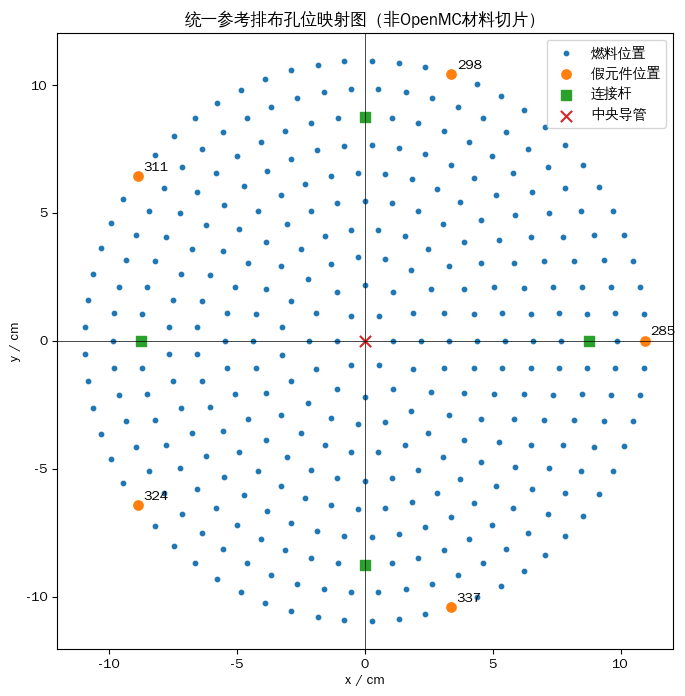

孔位图： ~/SZU_MNSR_Opt/build/reference_position_map.png


In [11]:
BUILD_DIR = Path("build")
BUILD_DIR.mkdir(exist_ok=True)
REFERENCE_POSITION_MAP_PATH = BUILD_DIR / "reference_position_map.png"

fuel_rows = ordinary_positions_df.loc[
    ordinary_positions_df["component_type"] == "fuel"
]
tie_rod_rows = physical_positions_df.loc[
    physical_positions_df["position_category"] == "tie_rod"
]
central_rows = physical_positions_df.loc[
    physical_positions_df["position_category"] == "central"
]

figure, axis = plt.subplots(figsize=(8, 8))
axis.scatter(fuel_rows["x_cm"], fuel_rows["y_cm"], s=10, label="燃料位置")
axis.scatter(dummy_rows["x_cm"], dummy_rows["y_cm"], s=45, label="假元件位置")
axis.scatter(tie_rod_rows["x_cm"], tie_rod_rows["y_cm"], s=45, marker="s", label="连接杆")
axis.scatter(central_rows["x_cm"], central_rows["y_cm"], s=65, marker="x", label="中央导管")

for row in dummy_rows.itertuples(index=False):
    axis.annotate(
        str(row.ordinary_position_id),
        (row.x_cm, row.y_cm),
        xytext=(4, 4),
        textcoords="offset points",
    )

axis.axhline(0.0, color="black", linewidth=0.5)
axis.axvline(0.0, color="black", linewidth=0.5)
axis.set_aspect("equal")
axis.set_xlabel("x / cm")
axis.set_ylabel("y / cm")
axis.set_title("统一参考排布孔位映射图（非OpenMC材料切片）")
axis.legend()
figure.savefig(REFERENCE_POSITION_MAP_PATH, dpi=200, bbox_inches="tight")
plt.show()

print("孔位图：", REFERENCE_POSITION_MAP_PATH.resolve())

## 9 legacy_simplified有限高度边界

本节至第23节保留修改前的统一23 cm教学基线，供后续敏感性比较。该模型把上下真空边界放在±11.5 cm，并把容器外壁直接设为径向真空；它不再作为默认参考模型。

In [12]:
z_bottom_surface = openmc.ZPlane(
    z0=Z_BOTTOM,
    boundary_type="vacuum",
    name="Bottom vacuum boundary",
)
z_top_surface = openmc.ZPlane(
    z0=Z_TOP,
    boundary_type="vacuum",
    name="Top vacuum boundary",
)

axial_region = +z_bottom_surface & -z_top_surface
print("有限轴向区域已建立。")

有限轴向区域已建立。


## 10 legacy_simplified径向边界

以下边界完整保留修改前模型。新的`iaea_reference`参数化函数会创建自己独立的Surface，不复用这些可变对象。

In [13]:
core_boundary = openmc.ZCylinder(r=R_CORE, name="Core outer boundary")
be_inner_boundary = openmc.ZCylinder(r=R_BE_INNER, name="Beryllium inner boundary")
be_outer_boundary = openmc.ZCylinder(r=R_BE_OUTER, name="Beryllium outer boundary")
vessel_inner_boundary = openmc.ZCylinder(r=R_VESSEL_INNER, name="Vessel inner boundary")
vessel_outer_boundary = openmc.ZCylinder(
    r=R_VESSEL_OUTER,
    boundary_type="vacuum",
    name="Vessel outer vacuum boundary",
)

assert R_CORE < R_BE_INNER < R_BE_OUTER < R_VESSEL_INNER < R_VESSEL_OUTER

for name, radius in {
    "堆芯外边界": R_CORE,
    "侧铍内边界": R_BE_INNER,
    "侧铍外边界": R_BE_OUTER,
    "容器内边界": R_VESSEL_INNER,
    "容器外边界": R_VESSEL_OUTER,
}.items():
    print(f"{name}: {radius} cm")

堆芯外边界: 11.5 cm
侧铍内边界: 11.55 cm
侧铍外边界: 21.75 cm
容器内边界: 30.0 cm
容器外边界: 31.0 cm


## 11 中央控制棒状态

控制棒状态集中在下面一个变量中。优化阶段默认使用`withdrawn`，表示镉控制棒离开本文轴向计算区域；`inserted`则显式建立铝芯、镉管和SS-304包管。控制棒位置固定，不是假元件优化变量，最终候选方案可再切换到插入状态计算。

In [14]:
CONTROL_ROD_STATE = "withdrawn"

if CONTROL_ROD_STATE not in {"withdrawn", "inserted"}:
    raise ValueError(
        "CONTROL_ROD_STATE只允许'withdrawn'或'inserted'。"
    )

print("控制棒状态：", CONTROL_ROD_STATE)

控制棒状态： withdrawn


## 12 中央控制棒导管与控制棒状态

中央导管内外半径固定为0.45 cm和0.60 cm。拔出状态下导管内部全部为水且没有镉Cell；插入状态下依次建立中心铝棒、镉管、0.005 cm简化水隙、SS-304包管、外部水区和LT-21导管。

In [15]:
guide_inner_cylinder = openmc.ZCylinder(
    r=R_GUIDE_INNER,
    name="Control guide inner surface",
)
guide_outer_cylinder = openmc.ZCylinder(
    r=R_GUIDE_OUTER,
    name="Control guide outer surface",
)

central_control_cells = []

if CONTROL_ROD_STATE == "withdrawn":
    central_control_cells.append(openmc.Cell(
        name="Withdrawn guide internal water",
        fill=material_map["water"],
        region=-guide_inner_cylinder & axial_region,
    ))
else:
    control_inner_cylinder = openmc.ZCylinder(
        r=R_CONTROL_INNER_AL,
        name="Control inner aluminum outer surface",
    )
    cadmium_outer_cylinder = openmc.ZCylinder(
        r=R_CADMIUM_OUTER,
        name="Cadmium tube outer surface",
    )
    ss304_inner_cylinder = openmc.ZCylinder(
        r=R_SS304_INNER,
        name="SS-304 control clad inner surface",
    )
    ss304_outer_cylinder = openmc.ZCylinder(
        r=R_SS304_OUTER,
        name="SS-304 control clad outer surface",
    )

    central_control_cells.extend([
        openmc.Cell(
            name="Control rod inner aluminum",
            fill=material_map["control_rod_inner"],
            region=-control_inner_cylinder & axial_region,
        ),
        openmc.Cell(
            name="Cadmium absorber tube",
            fill=material_map["cadmium"],
            region=(
                +control_inner_cylinder
                & -cadmium_outer_cylinder
                & axial_region
            ),
        ),
        openmc.Cell(
            name="Cadmium to SS-304 simplified water gap",
            fill=material_map["water"],
            region=(
                +cadmium_outer_cylinder
                & -ss304_inner_cylinder
                & axial_region
            ),
        ),
        openmc.Cell(
            name="SS-304 control rod cladding",
            fill=material_map["control_rod_clad"],
            region=(
                +ss304_inner_cylinder
                & -ss304_outer_cylinder
                & axial_region
            ),
        ),
        openmc.Cell(
            name="Control rod to guide water",
            fill=material_map["water"],
            region=(
                +ss304_outer_cylinder
                & -guide_inner_cylinder
                & axial_region
            ),
        ),
    ])

central_control_cells.append(openmc.Cell(
    name="LT-21 control guide tube",
    fill=material_map["guide_tube"],
    region=(
        +guide_inner_cylinder
        & -guide_outer_cylinder
        & axial_region
    ),
))

print("中央构件Cell数量：", len(central_control_cells))

中央构件Cell数量： 2


## 13 燃料元件、假元件和连接杆创建函数

三个简短函数把重复的棒体建模步骤集中起来，但不会隐藏整体几何流程。燃料和假元件名称包含稳定普通孔位编号，连接杆名称包含固定圈号和局部编号，方便后续筛选与检查。

In [16]:
def create_fuel_element(
    position_row,
    axial_region_override=None,
    material_map_override=None,
):
    """在一个普通孔位建立燃料芯体、包壳及其元数据。"""
    active_axial_region = (
        axial_region
        if axial_region_override is None
        else axial_region_override
    )
    active_material_map = (
        material_map
        if material_map_override is None
        else material_map_override
    )
    position_id = int(position_row["ordinary_position_id"])
    x_cm = float(position_row["x_cm"])
    y_cm = float(position_row["y_cm"])

    meat_surface = openmc.ZCylinder(
        x0=x_cm,
        y0=y_cm,
        r=R_FUEL_MEAT,
        name=f"Fuel meat outer pos {position_id}",
    )
    clad_surface = openmc.ZCylinder(
        x0=x_cm,
        y0=y_cm,
        r=R_FUEL_CLAD,
        name=f"Fuel clad outer pos {position_id}",
    )
    meat_cell = openmc.Cell(
        name=f"fuel_meat_pos_{position_id}",
        fill=active_material_map["fuel"],
        region=-meat_surface & active_axial_region,
    )
    clad_cell = openmc.Cell(
        name=f"fuel_clad_pos_{position_id}",
        fill=active_material_map["fuel_clad"],
        region=(
            +meat_surface
            & -clad_surface
            & active_axial_region
        ),
    )
    metadata = {
        "ordinary_position_id": position_id,
        "ring_index": int(position_row["ring_index"]),
        "local_index": int(position_row["local_index"]),
    }
    return meat_cell, clad_cell, clad_surface, metadata


def create_dummy_element(
    position_row,
    axial_region_override=None,
    material_map_override=None,
):
    """在一个普通孔位建立实心铝合金假元件。"""
    active_axial_region = (
        axial_region
        if axial_region_override is None
        else axial_region_override
    )
    active_material_map = (
        material_map
        if material_map_override is None
        else material_map_override
    )
    position_id = int(position_row["ordinary_position_id"])
    outer_surface = openmc.ZCylinder(
        x0=float(position_row["x_cm"]),
        y0=float(position_row["y_cm"]),
        r=R_DUMMY,
        name=f"Dummy outer pos {position_id}",
    )
    cell = openmc.Cell(
        name=f"dummy_pos_{position_id}",
        fill=active_material_map["dummy"],
        region=-outer_surface & active_axial_region,
    )
    metadata = {"ordinary_position_id": position_id}
    return cell, outer_surface, metadata


def create_tie_rod(
    position_row,
    axial_region_override=None,
    material_map_override=None,
):
    """在第8圈固定孔位建立实心铝合金连接杆。"""
    active_axial_region = (
        axial_region
        if axial_region_override is None
        else axial_region_override
    )
    active_material_map = (
        material_map
        if material_map_override is None
        else material_map_override
    )
    ring_index = int(position_row["ring_index"])
    local_index = int(position_row["local_index"])
    outer_surface = openmc.ZCylinder(
        x0=float(position_row["x_cm"]),
        y0=float(position_row["y_cm"]),
        r=R_TIE_ROD,
        name=f"Tie rod outer ring {ring_index} local {local_index}",
    )
    cell = openmc.Cell(
        name=f"tie_rod_ring_{ring_index}_local_{local_index}",
        fill=active_material_map["tie_rod"],
        region=-outer_surface & active_axial_region,
    )
    metadata = {"ring_index": ring_index, "local_index": local_index}
    return cell, outer_surface, metadata

## 14 棒状构件批量生成

按照普通孔位表逐个建立345根燃料元件和5根假元件，再单独建立4根固定连接杆。每根棒的外圆柱按圈保存，供下一步水区仅扣除本圈棒体。

In [17]:
geometry_cells = list(central_control_cells)
fuel_meat_cells = []
fuel_clad_cells = []
dummy_cells = []
tie_rod_cells = []
fuel_element_metadata = []
dummy_element_metadata = []
tie_rod_metadata = []

rod_outer_surfaces_by_ring = {
    ring_index: []
    for ring_index in range(len(RING_DISTRIBUTION))
}

for _, position_row in ordinary_positions_df.iterrows():
    ring_index = int(position_row["ring_index"])
    if position_row["component_type"] == "fuel":
        meat_cell, clad_cell, outer_surface, metadata = (
            create_fuel_element(position_row)
        )
        fuel_meat_cells.append(meat_cell)
        fuel_clad_cells.append(clad_cell)
        fuel_element_metadata.append(metadata)
        geometry_cells.extend([meat_cell, clad_cell])
    else:
        dummy_cell, outer_surface, metadata = create_dummy_element(
            position_row
        )
        dummy_cells.append(dummy_cell)
        dummy_element_metadata.append(metadata)
        geometry_cells.append(dummy_cell)

    rod_outer_surfaces_by_ring[ring_index].append(outer_surface)

for _, position_row in tie_rod_rows.iterrows():
    tie_cell, outer_surface, metadata = create_tie_rod(position_row)
    tie_rod_cells.append(tie_cell)
    tie_rod_metadata.append(metadata)
    geometry_cells.append(tie_cell)
    rod_outer_surfaces_by_ring[8].append(outer_surface)

assert len(fuel_meat_cells) == 345
assert len(fuel_clad_cells) == 345
assert len(dummy_cells) == 5
assert len(tie_rod_cells) == 4

print("燃料芯体Cell：", len(fuel_meat_cells))
print("燃料包壳Cell：", len(fuel_clad_cells))
print("假元件Cell：", len(dummy_cells))
print("连接杆Cell：", len(tie_rod_cells))

燃料芯体Cell： 345
燃料包壳Cell： 345
假元件Cell： 5
连接杆Cell： 4


## 15 按圈层划分堆芯水区

堆芯水不使用包含350多个圆柱补集的单一复杂表达式，而是分成中央区和第1至第10圈共11个水Cell。首个边界放在导管外表面与第1圈棒体内缘之间，其余边界位于相邻圈中心半径中点；每个水Cell只扣除本圈棒体。

In [18]:
first_boundary_radius = 0.5 * (
    R_GUIDE_OUTER
    + (PITCH - R_FUEL_CLAD)
)
internal_water_boundary_radii = [first_boundary_radius]
internal_water_boundary_radii.extend(
    0.5 * (
        ring_index * PITCH
        + (ring_index + 1) * PITCH
    )
    for ring_index in range(1, 10)
)

internal_water_boundaries = [
    openmc.ZCylinder(
        r=radius,
        name=f"Core water boundary {index}",
    )
    for index, radius in enumerate(internal_water_boundary_radii)
]

assert len(internal_water_boundaries) == 10
assert all(
    inner < outer
    for inner, outer in zip(
        internal_water_boundary_radii,
        internal_water_boundary_radii[1:],
    )
)
assert R_GUIDE_OUTER < first_boundary_radius < PITCH - R_FUEL_CLAD
for ring_index in range(1, 10):
    boundary_radius = internal_water_boundary_radii[ring_index]
    assert ring_index * PITCH + R_FUEL_CLAD < boundary_radius
    assert boundary_radius < (ring_index + 1) * PITCH - R_FUEL_CLAD
assert 10 * PITCH + max(R_FUEL_CLAD, R_DUMMY) < R_CORE

core_water_cells = []
for ring_index in range(len(RING_DISTRIBUTION)):
    if ring_index == 0:
        water_region = -internal_water_boundaries[0] & axial_region
        water_region &= +guide_outer_cylinder
    elif ring_index == 10:
        water_region = (
            +internal_water_boundaries[-1]
            & -core_boundary
            & axial_region
        )
    else:
        water_region = (
            +internal_water_boundaries[ring_index - 1]
            & -internal_water_boundaries[ring_index]
            & axial_region
        )

    for outer_surface in rod_outer_surfaces_by_ring[ring_index]:
        water_region &= +outer_surface

    water_cell = openmc.Cell(
        name=f"core_water_ring_{ring_index}",
        fill=material_map["water"],
        region=water_region,
    )
    core_water_cells.append(water_cell)
    geometry_cells.append(water_cell)

assert len(core_water_cells) == 11
print("堆芯分圈水Cell数量：", len(core_water_cells))
print("内部分界半径（cm）：", internal_water_boundary_radii)

堆芯分圈水Cell数量： 11
内部分界半径（cm）： [0.71, 1.6425, 2.7375, 3.8325, 4.9275, 6.0225, 7.1175, 8.2125, 9.307500000000001, 10.4025]


## 16 legacy_simplified外部反射层与容器

这里保留侧铍、外水区和容器都被统一23 cm轴向区域截断的旧组装方式。新版模型在后面的参数化接口中使用不同轴向范围。

In [19]:
core_to_beryllium_water_cell = openmc.Cell(
    name="Core to beryllium water gap",
    fill=material_map["water"],
    region=+core_boundary & -be_inner_boundary & axial_region,
)
beryllium_reflector_cell = openmc.Cell(
    name="Side beryllium reflector",
    fill=material_map["beryllium"],
    region=+be_inner_boundary & -be_outer_boundary & axial_region,
)
reflector_to_vessel_water_cell = openmc.Cell(
    name="Beryllium to vessel water",
    fill=material_map["water"],
    region=+be_outer_boundary & -vessel_inner_boundary & axial_region,
)
vessel_wall_cell = openmc.Cell(
    name="LT-21 reactor vessel wall",
    fill=material_map["vessel"],
    region=+vessel_inner_boundary & -vessel_outer_boundary & axial_region,
)

external_structure_cells = [
    core_to_beryllium_water_cell,
    beryllium_reflector_cell,
    reflector_to_vessel_water_cell,
    vessel_wall_cell,
]
geometry_cells.extend(external_structure_cells)

assert vessel_wall_cell.fill is material_map["vessel"]
assert vessel_wall_cell.fill is not material_map["fuel_clad"]
print("外部结构Cell数量：", len(external_structure_cells))

外部结构Cell数量： 4


## 17 组装OpenMC几何模型

所有中央构件、棒体、分圈水区和外部结构现在装入根宇宙，并创建`openmc.Geometry`。本单元只组装对象，不导出XML。

In [20]:
root_universe = openmc.Universe(
    name="MNSR root universe",
    cells=geometry_cells,
)
geometry = openmc.Geometry(root_universe)

print("根宇宙Cell数量：", len(root_universe.cells))

根宇宙Cell数量： 716


## 18 几何模型基础检查

本单元检查位置数量、坐标和编号唯一性、燃料与假元件集合互斥、Cell名称唯一性、控制棒状态以及有限三维包围盒。及早断言可以阻止错误排布进入后续优化或输运计算。

In [21]:
assert len(physical_positions_df) == 355
assert (physical_positions_df["position_category"] == "central").sum() == 1
assert len(tie_rod_cells) == 4
assert len(ordinary_positions_df) == 350
assert len(fuel_meat_cells) == 345
assert len(dummy_cells) == 5

coordinate_keys = {
    (round(row.x_cm, 12), round(row.y_cm, 12))
    for row in physical_positions_df.itertuples(index=False)
}
assert len(coordinate_keys) == 355
assert ordinary_positions_df["ordinary_position_id"].is_unique
assert fuel_position_ids.isdisjoint(dummy_position_ids)
assert fuel_position_ids | dummy_position_ids == set(range(350))
assert len({cell.name for cell in fuel_meat_cells}) == 345
assert len({cell.name for cell in fuel_clad_cells}) == 345
assert len({cell.name for cell in dummy_cells}) == 5

if CONTROL_ROD_STATE == "withdrawn":
    assert not any(
        "cadmium" in cell.name.lower()
        or cell.fill is material_map["cadmium"]
        for cell in geometry_cells
    )
else:
    assert any(cell.fill is material_map["cadmium"] for cell in geometry_cells)
    assert any(
        cell.fill is material_map["control_rod_clad"]
        for cell in geometry_cells
    )

bounding_box = geometry.bounding_box
lower_left = np.asarray(bounding_box.lower_left, dtype=float)
upper_right = np.asarray(bounding_box.upper_right, dtype=float)

print("geometry.bounding_box lower_left：", lower_left)
print("geometry.bounding_box upper_right：", upper_right)

assert np.all(np.isfinite(lower_left))
assert np.all(np.isfinite(upper_right))
assert math.isclose(lower_left[2], Z_BOTTOM, abs_tol=1.0e-12)
assert math.isclose(upper_right[2], Z_TOP, abs_tol=1.0e-12)

print("几何数量和有限边界检查通过。")

geometry.bounding_box lower_left： [-31.  -31.  -11.5]
geometry.bounding_box upper_right： [31.  31.  11.5]
几何数量和有限边界检查通过。


## 19 legacy_simplified绘图准备

修改前模型仍可通过`model_variant="legacy_simplified"`构建。本轮不再重复生成旧版XY/XZ图片，绘图资源用于检查默认的`iaea_reference`模型。

In [ ]:
from unittest.mock import PropertyMock, patch

openmc_executable_candidates = [
    Path(sys.executable).with_name("openmc"),
    Path(sys.prefix) / "envs" / "openmc-env" / "bin" / "openmc",
]
OPENMC_EXECUTABLE = next(
    (path for path in openmc_executable_candidates if path.is_file()),
    None,
)
if OPENMC_EXECUTABLE is None:
    raise FileNotFoundError(
        "找不到OpenMC可执行程序，无法生成几何切片图。"
    )

plot_colors = {
    material_map["fuel"]: "gold",
    material_map["fuel_clad"]: "silver",
    material_map["dummy"]: "lightgray",
    material_map["guide_tube"]: "darkgray",
    material_map["control_rod_clad"]: "slategray",
    material_map["water"]: "lightblue",
    material_map["beryllium"]: "green",
    material_map["cadmium"]: "navy",
}

print("OpenMC几何绘图可执行程序：", OPENMC_EXECUTABLE)
print("旧版切片不重复生成；将在参数化接口验证中绘制IAEA参考模型。")

## 20 legacy_simplified绘图说明

旧版图像与完整修改前Notebook已保存在`legacy/`备份中。新版全局验收图统一输出到`build/iaea_reference_geometry/`。

In [ ]:
print("legacy_simplified模型对象保留；本单元不调用外部绘图器。")

## 21 导出孔位编号与元件类型表

`position_table.csv`是后续优化算法与OpenMC几何之间的映射。优化只修改5个普通孔位编号；中央导管和连接杆的普通编号为空，不进入优化空间。

In [24]:
ordinary_component_lookup = ordinary_positions_df[[
    "physical_position_id",
    "ordinary_position_id",
    "component_type",
]]
position_table = physical_positions_df.merge(
    ordinary_component_lookup,
    on="physical_position_id",
    how="left",
)
position_table["ordinary_position_id"] = (
    position_table["ordinary_position_id"].astype("Int64")
)
position_table["component_type"] = position_table[
    "component_type"
].fillna(position_table["position_category"])
position_table = position_table[[
    "physical_position_id",
    "ordinary_position_id",
    "ring_index",
    "local_index",
    "x_cm",
    "y_cm",
    "position_category",
    "component_type",
]]

POSITION_TABLE_PATH = BUILD_DIR / "position_table.csv"
position_table.to_csv(POSITION_TABLE_PATH, index=False, encoding="utf-8")

display(position_table.head(8))
print("孔位表：", POSITION_TABLE_PATH.resolve())

,physical_position_id,ordinary_position_id,ring_index,local_index,x_cm,y_cm,position_category,component_type
0,0,<NA>,0,0,0.0000,0.000000e+00,central,central
1,1,0,1,0,1.0950,0.000000e+00,ordinary,fuel
2,2,1,1,1,0.5475,9.482978e-01,ordinary,fuel
3,3,2,1,2,-0.5475,9.482978e-01,ordinary,fuel
4,4,3,1,3,-1.0950,1.340988e-16,ordinary,fuel
5,5,4,1,4,-0.5475,-9.482978e-01,ordinary,fuel
6,6,5,1,5,0.5475,-9.482978e-01,ordinary,fuel
7,7,6,2,0,2.1900,0.000000e+00,ordinary,fuel


孔位表： ~/SZU_MNSR_Opt/build/position_table.csv


## 22 导出legacy_simplified几何基线

旧模型XML单独保存，避免与新版默认参考几何混淆。

In [ ]:
LEGACY_BUILD_DIR = Path("build/legacy_simplified_geometry")
LEGACY_BUILD_DIR.mkdir(parents=True, exist_ok=True)
GEOMETRY_XML_PATH = LEGACY_BUILD_DIR / "geometry.xml"

geometry.export_to_xml(path=GEOMETRY_XML_PATH)

print("legacy_simplified geometry.xml：", GEOMETRY_XML_PATH.resolve())
print("文件存在：", GEOMETRY_XML_PATH.is_file())
print("文件大小：", GEOMETRY_XML_PATH.stat().st_size, "bytes")

## 23 查看legacy_simplified导出的geometry.xml

In [26]:
with GEOMETRY_XML_PATH.open("r", encoding="utf-8") as xml_file:
    for _ in range(30):
        line = xml_file.readline()
        if not line:
            break
        print(line.rstrip())

<?xml version='1.0' encoding='UTF-8'?>
<geometry>
  <cell id="1" name="Withdrawn guide internal water" material="6" region="-8 1 -2" universe="1"/>
  <cell id="2" name="LT-21 control guide tube" material="4" region="8 -9 1 -2" universe="1"/>
  <cell id="3" name="fuel_meat_pos_0" material="1" region="-10 1 -2" universe="1"/>
  <cell id="4" name="fuel_clad_pos_0" material="2" region="10 -11 1 -2" universe="1"/>
  <cell id="5" name="fuel_meat_pos_1" material="1" region="-12 1 -2" universe="1"/>
  <cell id="6" name="fuel_clad_pos_1" material="2" region="12 -13 1 -2" universe="1"/>
  <cell id="7" name="fuel_meat_pos_2" material="1" region="-14 1 -2" universe="1"/>
  <cell id="8" name="fuel_clad_pos_2" material="2" region="14 -15 1 -2" universe="1"/>
  <cell id="9" name="fuel_meat_pos_3" material="1" region="-16 1 -2" universe="1"/>
  <cell id="10" name="fuel_clad_pos_3" material="2" region="16 -17 1 -2" universe="1"/>
  <cell id="11" name="fuel_meat_pos_4" material="1" region="-18 1 -2" uni

## 参数化几何构建接口：legacy与IAEA参考版本

`build_geometry_for_scheme`保留原有假元件方案与控制棒接口，并增加：

- `model_variant="iaea_reference"`：默认，包含有限高度侧铍、底铍、独立导管高度、容器外池水和远场真空边界；
- `model_variant="legacy_simplified"`：完整保留修改前统一23 cm模型；
- `top_be_thickness_cm=0.0`：初始装料默认无顶部铍，只有显式大于0时才建立敏感性分析结构。
- `control_rod_position_cm`：仅用于`iaea_reference`的inserted状态。0 cm是本文统一fully-inserted参考，正值表示Cd、Al棒和SS管同步向+z拔出；导管固定。

IAEA-TECDOC-1844没有给出position=0时Cd端点的绝对z坐标。因此本Notebook明确采用论文建模假设：26.6 cm Cd吸收段在0 cm位置关于堆芯中心z=0对称。这不是对实际as-built插入位置的声称。

侧铍以活性区中面对称布置是本文根据尺寸建立的轴向定位假设。

池水范围是用于降低数值截断边界影响的计算区域，不是对实际池体尺寸的精确复现；其尺寸后续需要通过边界距离敏感性计算检验。

In [ ]:
def _build_legacy_simplified_geometry(
    dummy_position_ids,
    control_rod_state="withdrawn",
    export_directory=None,
    create_plots=False,
):
    """根据5个普通孔位编号重建一套独立的有限高度OpenMC几何。"""
    allowed_ids = set(
        int(position_id)
        for position_id in ordinary_positions_df["ordinary_position_id"]
    )
    normalized_dummy_ids = validate_dummy_position_ids(
        dummy_position_ids,
        allowed_position_ids=allowed_ids,
    )
    if control_rod_state not in {"withdrawn", "inserted"}:
        raise ValueError(
            "control_rod_state只允许'withdrawn'或'inserted'。"
        )
    if not isinstance(create_plots, bool):
        raise ValueError("create_plots必须是True或False。")

    scheme_dummy_ids = set(normalized_dummy_ids)
    scheme_fuel_ids = allowed_ids - scheme_dummy_ids
    scheme_positions_df = ordinary_positions_df.copy(deep=True)
    scheme_positions_df["component_type"] = np.where(
        scheme_positions_df["ordinary_position_id"].isin(
            scheme_dummy_ids
        ),
        "dummy",
        "fuel",
    )

    # 每次调用都创建新的轴向与宏观径向Surface。
    scheme_z_bottom = openmc.ZPlane(
        z0=Z_BOTTOM,
        boundary_type="vacuum",
        name="Scheme bottom vacuum boundary",
    )
    scheme_z_top = openmc.ZPlane(
        z0=Z_TOP,
        boundary_type="vacuum",
        name="Scheme top vacuum boundary",
    )
    scheme_axial_region = +scheme_z_bottom & -scheme_z_top

    scheme_core_boundary = openmc.ZCylinder(
        r=R_CORE,
        name="Scheme core outer boundary",
    )
    scheme_be_inner = openmc.ZCylinder(
        r=R_BE_INNER,
        name="Scheme beryllium inner boundary",
    )
    scheme_be_outer = openmc.ZCylinder(
        r=R_BE_OUTER,
        name="Scheme beryllium outer boundary",
    )
    scheme_vessel_inner = openmc.ZCylinder(
        r=R_VESSEL_INNER,
        name="Scheme vessel inner boundary",
    )
    scheme_vessel_outer = openmc.ZCylinder(
        r=R_VESSEL_OUTER,
        boundary_type="vacuum",
        name="Scheme vessel outer vacuum boundary",
    )

    # 中央导管和可选插入控制棒同样使用本次调用专属Surface。
    scheme_guide_inner = openmc.ZCylinder(
        r=R_GUIDE_INNER,
        name="Scheme control guide inner surface",
    )
    scheme_guide_outer = openmc.ZCylinder(
        r=R_GUIDE_OUTER,
        name="Scheme control guide outer surface",
    )
    scheme_cells = []
    scheme_control_cells = []

    if control_rod_state == "withdrawn":
        scheme_control_cells.append(openmc.Cell(
            name="Withdrawn guide internal water",
            fill=material_map["water"],
            region=-scheme_guide_inner & scheme_axial_region,
        ))
    else:
        scheme_control_inner = openmc.ZCylinder(
            r=R_CONTROL_INNER_AL,
            name="Scheme control inner aluminum outer surface",
        )
        scheme_cadmium_outer = openmc.ZCylinder(
            r=R_CADMIUM_OUTER,
            name="Scheme cadmium tube outer surface",
        )
        scheme_ss304_inner = openmc.ZCylinder(
            r=R_SS304_INNER,
            name="Scheme SS-304 clad inner surface",
        )
        scheme_ss304_outer = openmc.ZCylinder(
            r=R_SS304_OUTER,
            name="Scheme SS-304 clad outer surface",
        )
        scheme_control_cells.extend([
            openmc.Cell(
                name="Control rod inner aluminum",
                fill=material_map["control_rod_inner"],
                region=(
                    -scheme_control_inner
                    & scheme_axial_region
                ),
            ),
            openmc.Cell(
                name="Cadmium absorber tube",
                fill=material_map["cadmium"],
                region=(
                    +scheme_control_inner
                    & -scheme_cadmium_outer
                    & scheme_axial_region
                ),
            ),
            openmc.Cell(
                name="Cadmium to SS-304 simplified water gap",
                fill=material_map["water"],
                region=(
                    +scheme_cadmium_outer
                    & -scheme_ss304_inner
                    & scheme_axial_region
                ),
            ),
            openmc.Cell(
                name="SS-304 control rod cladding",
                fill=material_map["control_rod_clad"],
                region=(
                    +scheme_ss304_inner
                    & -scheme_ss304_outer
                    & scheme_axial_region
                ),
            ),
            openmc.Cell(
                name="Control rod to guide water",
                fill=material_map["water"],
                region=(
                    +scheme_ss304_outer
                    & -scheme_guide_inner
                    & scheme_axial_region
                ),
            ),
        ])

    scheme_control_cells.append(openmc.Cell(
        name="LT-21 control guide tube",
        fill=material_map["guide_tube"],
        region=(
            +scheme_guide_inner
            & -scheme_guide_outer
            & scheme_axial_region
        ),
    ))
    scheme_cells.extend(scheme_control_cells)

    scheme_fuel_meat_cells = []
    scheme_fuel_clad_cells = []
    scheme_dummy_cells = []
    scheme_tie_rod_cells = []
    scheme_outer_surfaces_by_ring = {
        ring_index: []
        for ring_index in range(len(RING_DISTRIBUTION))
    }

    for _, position_row in scheme_positions_df.iterrows():
        ring_index = int(position_row["ring_index"])
        if position_row["component_type"] == "fuel":
            meat_cell, clad_cell, outer_surface, _ = (
                create_fuel_element(
                    position_row,
                    axial_region_override=scheme_axial_region,
                    material_map_override=material_map,
                )
            )
            scheme_fuel_meat_cells.append(meat_cell)
            scheme_fuel_clad_cells.append(clad_cell)
            scheme_cells.extend([meat_cell, clad_cell])
        else:
            dummy_cell, outer_surface, _ = create_dummy_element(
                position_row,
                axial_region_override=scheme_axial_region,
                material_map_override=material_map,
            )
            scheme_dummy_cells.append(dummy_cell)
            scheme_cells.append(dummy_cell)
        scheme_outer_surfaces_by_ring[ring_index].append(
            outer_surface
        )

    scheme_tie_rows = physical_positions_df.loc[
        physical_positions_df["position_category"] == "tie_rod"
    ]
    for _, position_row in scheme_tie_rows.iterrows():
        tie_cell, outer_surface, _ = create_tie_rod(
            position_row,
            axial_region_override=scheme_axial_region,
            material_map_override=material_map,
        )
        scheme_tie_rod_cells.append(tie_cell)
        scheme_cells.append(tie_cell)
        scheme_outer_surfaces_by_ring[8].append(outer_surface)

    # 复用经过验证的11个分圈水区半径逻辑。
    scheme_first_water_boundary = 0.5 * (
        R_GUIDE_OUTER + (PITCH - R_FUEL_CLAD)
    )
    scheme_water_radii = [scheme_first_water_boundary]
    scheme_water_radii.extend(
        0.5 * (
            ring_index * PITCH
            + (ring_index + 1) * PITCH
        )
        for ring_index in range(1, 10)
    )
    scheme_water_boundaries = [
        openmc.ZCylinder(
            r=radius,
            name=f"Scheme core water boundary {index}",
        )
        for index, radius in enumerate(scheme_water_radii)
    ]
    scheme_core_water_cells = []

    for ring_index in range(len(RING_DISTRIBUTION)):
        if ring_index == 0:
            water_region = (
                -scheme_water_boundaries[0]
                & scheme_axial_region
            )
            water_region &= +scheme_guide_outer
        elif ring_index == 10:
            water_region = (
                +scheme_water_boundaries[-1]
                & -scheme_core_boundary
                & scheme_axial_region
            )
        else:
            water_region = (
                +scheme_water_boundaries[ring_index - 1]
                & -scheme_water_boundaries[ring_index]
                & scheme_axial_region
            )
        for outer_surface in scheme_outer_surfaces_by_ring[ring_index]:
            water_region &= +outer_surface

        water_cell = openmc.Cell(
            name=f"core_water_ring_{ring_index}",
            fill=material_map["water"],
            region=water_region,
        )
        scheme_core_water_cells.append(water_cell)
        scheme_cells.append(water_cell)

    scheme_cells.extend([
        openmc.Cell(
            name="Core to beryllium water gap",
            fill=material_map["water"],
            region=(
                +scheme_core_boundary
                & -scheme_be_inner
                & scheme_axial_region
            ),
        ),
        openmc.Cell(
            name="Side beryllium reflector",
            fill=material_map["beryllium"],
            region=(
                +scheme_be_inner
                & -scheme_be_outer
                & scheme_axial_region
            ),
        ),
        openmc.Cell(
            name="Beryllium to vessel water",
            fill=material_map["water"],
            region=(
                +scheme_be_outer
                & -scheme_vessel_inner
                & scheme_axial_region
            ),
        ),
        openmc.Cell(
            name="LT-21 reactor vessel wall",
            fill=material_map["vessel"],
            region=(
                +scheme_vessel_inner
                & -scheme_vessel_outer
                & scheme_axial_region
            ),
        ),
    ])

    scheme_root_universe = openmc.Universe(
        name="Parameterized MNSR root universe",
        cells=scheme_cells,
    )
    scheme_geometry = openmc.Geometry(scheme_root_universe)

    scheme_component_lookup = scheme_positions_df[[
        "physical_position_id",
        "ordinary_position_id",
        "component_type",
    ]]
    scheme_position_table = physical_positions_df.merge(
        scheme_component_lookup,
        on="physical_position_id",
        how="left",
    )
    scheme_position_table["ordinary_position_id"] = (
        scheme_position_table["ordinary_position_id"].astype("Int64")
    )
    scheme_position_table["component_type"] = scheme_position_table[
        "component_type"
    ].fillna(scheme_position_table["position_category"])

    counts = {
        "physical_positions": 355,
        "ordinary_positions": 350,
        "fuel": len(scheme_fuel_meat_cells),
        "dummy": len(scheme_dummy_cells),
        "tie_rod": len(scheme_tie_rod_cells),
        "central": 1,
    }
    assert counts == {
        "physical_positions": 355,
        "ordinary_positions": 350,
        "fuel": 345,
        "dummy": 5,
        "tie_rod": 4,
        "central": 1,
    }

    output_files = {}
    resolved_export_directory = None
    if export_directory is not None:
        resolved_export_directory = Path(
            export_directory
        ).expanduser().resolve()
        if resolved_export_directory == Path.cwd().resolve():
            raise ValueError(
                "export_directory不能是项目根目录，请使用build下的子目录。"
            )
        resolved_export_directory.mkdir(parents=True, exist_ok=True)
        geometry_xml_path = resolved_export_directory / "geometry.xml"
        scheme_geometry.export_to_xml(path=geometry_xml_path)
        output_files["geometry_xml"] = geometry_xml_path

    if create_plots:
        if resolved_export_directory is None:
            scheme_name = "_".join(map(str, normalized_dummy_ids))
            plot_directory = (
                Path("build") / f"scheme_plots_{scheme_name}"
            ).resolve()
            plot_directory.mkdir(parents=True, exist_ok=True)
        else:
            plot_directory = resolved_export_directory

        from unittest.mock import PropertyMock, patch

        scheme_plot_colors = {
            material_map["fuel"]: "gold",
            material_map["fuel_clad"]: "silver",
            material_map["dummy"]: "lightgray",
            material_map["guide_tube"]: "darkgray",
            material_map["control_rod_clad"]: "slategray",
            material_map["water"]: "lightblue",
            material_map["beryllium"]: "green",
            material_map["cadmium"]: "navy",
        }
        with patch.object(
            openmc.Model,
            "is_initialized",
            new_callable=PropertyMock,
            return_value=False,
        ):
            scheme_xy_axes = scheme_geometry.plot(
                basis="xy",
                origin=(0.0, 0.0, 0.0),
                width=(62.0, 62.0),
                pixels=(1200, 1200),
                color_by="material",
                colors=scheme_plot_colors,
                show_overlaps=True,
                legend=True,
                legend_kwargs={"fontsize": 14},
                axis_units="cm",
                openmc_exec=OPENMC_EXECUTABLE,
            )
        scheme_xy_path = plot_directory / "geometry_xy.png"
        scheme_xy_axes.figure.savefig(
            scheme_xy_path,
            dpi=150,
            bbox_inches="tight",
        )
        plt.close(scheme_xy_axes.figure)

        with patch.object(
            openmc.Model,
            "is_initialized",
            new_callable=PropertyMock,
            return_value=False,
        ):
            scheme_xz_axes = scheme_geometry.plot(
                basis="xz",
                origin=(0.0, 0.0, 0.0),
                width=(62.0, 25.0),
                pixels=(1200, 600),
                color_by="material",
                colors=scheme_plot_colors,
                show_overlaps=True,
                legend=True,
                legend_kwargs={"fontsize": 14},
                axis_units="cm",
                openmc_exec=OPENMC_EXECUTABLE,
            )
        scheme_xz_path = plot_directory / "geometry_xz.png"
        scheme_xz_axes.figure.savefig(
            scheme_xz_path,
            dpi=150,
            bbox_inches="tight",
        )
        plt.close(scheme_xz_axes.figure)
        output_files["geometry_xy"] = scheme_xy_path
        output_files["geometry_xz"] = scheme_xz_path

    geometry_metadata = {
        "dummy_position_ids": normalized_dummy_ids,
        "fuel_position_ids": tuple(sorted(scheme_fuel_ids)),
        "fuel_meat_cells": scheme_fuel_meat_cells,
        "fuel_clad_cells": scheme_fuel_clad_cells,
        "dummy_cells": scheme_dummy_cells,
        "tie_rod_cells": scheme_tie_rod_cells,
        "position_table": scheme_position_table,
        "control_rod_state": control_rod_state,
        "counts": counts,
        "output_files": output_files,
    }
    return scheme_geometry, geometry_metadata

SOURCED_GEOMETRY_PARAMETERS = {
    "side_be_inner_radius_cm": R_SIDE_BE_INNER,
    "side_be_outer_radius_cm": R_SIDE_BE_OUTER,
    "side_be_height_cm": SIDE_BE_HEIGHT,
    "bottom_be_radius_cm": BOTTOM_BE_RADIUS,
    "bottom_be_hole_radius_cm": BOTTOM_BE_HOLE_RADIUS,
    "bottom_be_thickness_cm": BOTTOM_BE_THICKNESS,
    "bottom_to_side_gap_cm": BOTTOM_TO_SIDE_GAP,
    "initial_top_be_thickness_cm": INITIAL_TOP_BE_THICKNESS,
    "guide_tube_height_cm": GUIDE_TUBE_HEIGHT,
    "cadmium_absorber_height_cm": CD_ABSORBER_HEIGHT,
    "central_al_rod_height_cm": CONTROL_AL_ROD_HEIGHT,
    "external_ss_tube_height_cm": CONTROL_SS_TUBE_HEIGHT,
}

OMITTED_STRUCTURES = [
    "top and bottom grid plates",
    "fuel end plugs",
    "inner and outer irradiation channels",
    "reactivity regulating tubes",
    "fission chamber tube",
    "top beryllium tray",
    "complete control rod drive mechanism",
    "exact pool and pool liner structures",
]

RETAINED_SIMPLIFICATIONS = [
    "Fuel cladding full length is temporarily represented by the 23.0 cm active length.",
    "Dummy elements use the 23.0 cm simplified length.",
    "Tie rods use the 23.0 cm simplified length.",
    "Vessel radii 30.0/31.0 cm are retained project simplifications.",
]


def _common_geometry_assumptions(top_be_thickness_cm):
    assumptions = [
        "侧铍以活性区中面对称布置是本文根据尺寸建立的轴向定位假设。",
        "池水范围是用于降低数值截断边界影响的计算区域，不是对实际池体尺寸的精确复现；其尺寸后续需要通过边界距离敏感性计算检验。",
        "The vessel axial extent is a modelling assumption spanning the bottom reflector lower face to the higher of the guide top and optional top reflector top.",
        "The control guide is centered on the active fuel midplane.",
        CONTROL_ROD_AXIAL_MODEL_ASSUMPTION,
    ]
    if top_be_thickness_cm > 0.0:
        assumptions.append(
            "Non-zero top beryllium is a sensitivity-analysis assumption; it is not a verified initial-loading structure."
        )
    else:
        assumptions.append(
            "Initial loading uses no top beryllium, following the stated initial MNSR-SZ configuration."
        )
    return assumptions


def _clone_plot_compatible_beryllium():
    """为几何绘图临时兼容本机金属铍热散射表名称。"""
    import xml.etree.ElementTree as ET

    original = material_map["beryllium"]
    try:
        cross_sections = Path(
            openmc.config["cross_sections"]
        ).expanduser().resolve()
    except KeyError:
        return original
    if not cross_sections.is_file():
        return original

    library_root = ET.parse(cross_sections).getroot()
    thermal_names = {
        library.get("materials")
        for library in library_root.findall("library")
        if library.get("type") == "thermal"
    }
    if "c_Be_in_Be" in thermal_names or "c_Be" not in thermal_names:
        return original

    clone = openmc.Material(name="Beryllium Reflector plot alias")
    for nuclide in original.nuclides:
        clone.add_nuclide(
            nuclide.name,
            nuclide.percent,
            nuclide.percent_type,
        )
    if original.density is None:
        raise ValueError("金属铍材料缺少密度，无法建立绘图别名。")
    clone.set_density(original.density_units, original.density)
    if original.temperature is not None:
        clone.temperature = original.temperature
    clone.add_s_alpha_beta("c_Be")
    return clone



GEOMETRY_PLOT_TITLE_FONTSIZE = 24
GEOMETRY_PLOT_AXIS_LABEL_FONTSIZE = 21
GEOMETRY_PLOT_TICK_FONTSIZE = 18
GEOMETRY_PLOT_LEGEND_FONTSIZE = 18
GEOMETRY_PLOT_LEGEND_TITLE_FONTSIZE = 18
GEOMETRY_PLOT_SPINE_LINEWIDTH = 1.8
GEOMETRY_PLOT_TICK_WIDTH = 1.5
GEOMETRY_PLOT_TICK_LENGTH = 7
GEOMETRY_PLOT_DPI = 400


def _format_high_resolution_geometry_axes(
    axes,
    title,
    figure_size,
):
    """只放大画布和文字，不改变切片内容、范围、配色或英文文本。"""
    axes.figure.set_size_inches(*figure_size, forward=True)
    axes.set_title(
        title,
        fontsize=GEOMETRY_PLOT_TITLE_FONTSIZE,
        pad=18,
    )
    axes.xaxis.label.set_fontsize(
        GEOMETRY_PLOT_AXIS_LABEL_FONTSIZE
    )
    axes.yaxis.label.set_fontsize(
        GEOMETRY_PLOT_AXIS_LABEL_FONTSIZE
    )
    axes.xaxis.labelpad = 12
    axes.yaxis.labelpad = 12
    axes.tick_params(
        axis="both",
        which="major",
        labelsize=GEOMETRY_PLOT_TICK_FONTSIZE,
        width=GEOMETRY_PLOT_TICK_WIDTH,
        length=GEOMETRY_PLOT_TICK_LENGTH,
        pad=7,
    )
    for spine in axes.spines.values():
        spine.set_linewidth(GEOMETRY_PLOT_SPINE_LINEWIDTH)

    legend = axes.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_fontsize(GEOMETRY_PLOT_LEGEND_FONTSIZE)
        legend_title = legend.get_title()
        if legend_title.get_text():
            legend_title.set_fontsize(
                GEOMETRY_PLOT_LEGEND_TITLE_FONTSIZE
            )
        legend_frame = legend.get_frame()
        legend_frame.set_linewidth(1.6)
        legend_frame.set_edgecolor("black")
        legend.set_in_layout(True)

    return axes

def _serializable_geometry_metadata(metadata):
    """提取不含OpenMC对象和DataFrame的geometry_metadata。"""
    keys = [
        "geometry_model_version",
        "model_variant",
        "active_fuel_bounds",
        "side_be_bounds",
        "bottom_be_bounds",
        "guide_tube_bounds",
        "control_rod_position_cm",
        "control_rod_axial_model_assumption",
        "control_rod_axial_definition_version",
        "control_rod_axial_bounds",
        "pool_bounds",
        "vessel_bounds",
        "top_be_thickness_cm",
        "top_be_sensitivity_assumption",
        "sourced_geometry_parameters",
        "modelling_assumptions",
        "retained_simplifications",
        "omitted_structures",
        "control_rod_state",
        "counts",
        "dummy_position_ids",
        "fuel_position_ids",
        "vacuum_boundary_names",
    ]
    result = {}
    for key in keys:
        value = metadata[key]
        if isinstance(value, tuple):
            value = list(value)
        result[key] = value
    result["output_files"] = {
        name: str(path)
        for name, path in metadata["output_files"].items()
    }
    return result


def _build_iaea_reference_geometry(
    dummy_position_ids,
    control_rod_state="withdrawn",
    control_rod_position_cm=None,
    export_directory=None,
    create_plots=False,
    top_be_thickness_cm=0.0,
):
    """建立包含侧铍、底铍和计算池水的IAEA参考几何版本。"""
    allowed_ids = set(
        int(position_id)
        for position_id in ordinary_positions_df["ordinary_position_id"]
    )
    normalized_dummy_ids = validate_dummy_position_ids(
        dummy_position_ids,
        allowed_position_ids=allowed_ids,
    )
    if control_rod_state not in {"withdrawn", "inserted"}:
        raise ValueError(
            "control_rod_state只允许'withdrawn'或'inserted'。"
        )
    if control_rod_state == "withdrawn":
        if control_rod_position_cm is not None:
            raise ValueError(
                "withdrawn状态不建立可移动控制棒，control_rod_position_cm必须为None。"
            )
        normalized_control_rod_position_cm = None
    else:
        if control_rod_position_cm is None:
            control_rod_position_cm = CONTROL_ROD_FULLY_INSERTED_REFERENCE_CM
        if isinstance(control_rod_position_cm, bool) or not isinstance(
            control_rod_position_cm,
            (int, float, np.integer, np.floating),
        ):
            raise ValueError("control_rod_position_cm必须是实数。")
        normalized_control_rod_position_cm = float(control_rod_position_cm)
        if not np.isfinite(normalized_control_rod_position_cm):
            raise ValueError("control_rod_position_cm必须是有限实数。")
        if not 0.0 <= normalized_control_rod_position_cm <= 24.0:
            raise ValueError(
                "pilot控制棒位置必须位于0.0到24.0 cm之间。"
            )
    if not isinstance(create_plots, bool):
        raise ValueError("create_plots必须是True或False。")
    if isinstance(top_be_thickness_cm, bool) or not isinstance(
        top_be_thickness_cm, (int, float)
    ):
        raise ValueError("top_be_thickness_cm必须是实数。")
    top_be_thickness_cm = float(top_be_thickness_cm)
    if not 0.0 <= top_be_thickness_cm <= MAX_TOP_BE_THICKNESS:
        raise ValueError(
            "top_be_thickness_cm必须位于0.0到10.95 cm之间。"
        )

    scheme_dummy_ids = set(normalized_dummy_ids)
    scheme_fuel_ids = allowed_ids - scheme_dummy_ids
    scheme_positions_df = ordinary_positions_df.copy(deep=True)
    scheme_positions_df["component_type"] = np.where(
        scheme_positions_df["ordinary_position_id"].isin(
            scheme_dummy_ids
        ),
        "dummy",
        "fuel",
    )

    top_be_bottom = Z_SIDE_BE_TOP + TOP_TO_SIDE_GAP
    top_be_top = top_be_bottom + top_be_thickness_cm
    vessel_bottom = Z_BOTTOM_BE_BOTTOM
    vessel_top = max(
        Z_GUIDE_TOP,
        top_be_top if top_be_thickness_cm > 0.0 else Z_SIDE_BE_TOP,
    )

    # 所有Surface均在本次调用中独立创建。
    fuel_bottom_plane = openmc.ZPlane(
        z0=Z_FUEL_BOTTOM,
        name="IAEA active fuel bottom",
    )
    fuel_top_plane = openmc.ZPlane(
        z0=Z_FUEL_TOP,
        name="IAEA active fuel top",
    )
    side_be_bottom_plane = openmc.ZPlane(
        z0=Z_SIDE_BE_BOTTOM,
        name="IAEA side beryllium bottom",
    )
    side_be_top_plane = openmc.ZPlane(
        z0=Z_SIDE_BE_TOP,
        name="IAEA side beryllium top",
    )
    bottom_be_bottom_plane = openmc.ZPlane(
        z0=Z_BOTTOM_BE_BOTTOM,
        name="IAEA bottom beryllium bottom",
    )
    bottom_be_top_plane = openmc.ZPlane(
        z0=Z_BOTTOM_BE_TOP,
        name="IAEA bottom beryllium top",
    )
    guide_bottom_plane = openmc.ZPlane(
        z0=Z_GUIDE_BOTTOM,
        name="IAEA guide tube bottom",
    )
    guide_top_plane = openmc.ZPlane(
        z0=Z_GUIDE_TOP,
        name="IAEA guide tube top",
    )
    vessel_bottom_plane = openmc.ZPlane(
        z0=vessel_bottom,
        name="IAEA simplified vessel bottom",
    )
    vessel_top_plane = openmc.ZPlane(
        z0=vessel_top,
        name="IAEA simplified vessel top",
    )
    pool_bottom_plane = openmc.ZPlane(
        z0=Z_POOL_BOTTOM,
        boundary_type="vacuum",
        name="IAEA pool bottom vacuum boundary",
    )
    pool_top_plane = openmc.ZPlane(
        z0=Z_POOL_TOP,
        boundary_type="vacuum",
        name="IAEA pool top vacuum boundary",
    )

    core_boundary = openmc.ZCylinder(
        r=R_CORE,
        name="IAEA core outer boundary",
    )
    side_be_inner = openmc.ZCylinder(
        r=R_SIDE_BE_INNER,
        name="IAEA side beryllium inner surface",
    )
    side_be_outer = openmc.ZCylinder(
        r=R_SIDE_BE_OUTER,
        name="IAEA side beryllium outer surface",
    )
    bottom_be_outer = openmc.ZCylinder(
        r=BOTTOM_BE_RADIUS,
        name="IAEA bottom beryllium outer surface",
    )
    bottom_be_hole = openmc.ZCylinder(
        r=BOTTOM_BE_HOLE_RADIUS,
        name="IAEA bottom beryllium central water hole",
    )
    vessel_inner = openmc.ZCylinder(
        r=R_VESSEL_INNER,
        name="IAEA simplified vessel inner surface",
    )
    vessel_outer = openmc.ZCylinder(
        r=R_VESSEL_OUTER,
        name="IAEA simplified vessel outer surface",
    )
    pool_outer = openmc.ZCylinder(
        r=R_POOL_BOUNDARY,
        boundary_type="vacuum",
        name="IAEA pool radial vacuum boundary",
    )
    guide_inner = openmc.ZCylinder(
        r=R_GUIDE_INNER,
        name="IAEA control guide inner surface",
    )
    guide_outer = openmc.ZCylinder(
        r=R_GUIDE_OUTER,
        name="IAEA control guide outer surface",
    )

    fuel_axial_region = +fuel_bottom_plane & -fuel_top_plane
    side_be_axial_region = +side_be_bottom_plane & -side_be_top_plane
    bottom_be_axial_region = +bottom_be_bottom_plane & -bottom_be_top_plane
    guide_axial_region = +guide_bottom_plane & -guide_top_plane
    vessel_axial_region = +vessel_bottom_plane & -vessel_top_plane
    pool_region = (
        -pool_outer
        & +pool_bottom_plane
        & -pool_top_plane
    )

    cells = []
    control_cells = []
    guide_material_region = (
        +guide_inner & -guide_outer & guide_axial_region
    )
    central_corridor_region = -guide_outer & pool_region
    control_cells.append(openmc.Cell(
        name="IAEA LT-21 control guide tube",
        fill=material_map["guide_tube"],
        region=guide_material_region,
    ))

    control_rod_axial_bounds = None
    if control_rod_state == "withdrawn":
        control_cells.append(openmc.Cell(
            name="IAEA withdrawn central corridor water",
            fill=material_map["water"],
            region=central_corridor_region & ~guide_material_region,
        ))
    else:
        rod_shift = normalized_control_rod_position_cm
        cd_bottom = rod_shift - CD_ABSORBER_HEIGHT / 2.0
        cd_top = rod_shift + CD_ABSORBER_HEIGHT / 2.0
        al_bottom = rod_shift - CONTROL_AL_ROD_HEIGHT / 2.0
        al_top = rod_shift + CONTROL_AL_ROD_HEIGHT / 2.0
        ss_bottom = rod_shift - CONTROL_SS_TUBE_HEIGHT / 2.0
        ss_top = rod_shift + CONTROL_SS_TUBE_HEIGHT / 2.0
        cd_bottom_plane = openmc.ZPlane(
            z0=cd_bottom, name="IAEA movable Cd absorber bottom"
        )
        cd_top_plane = openmc.ZPlane(
            z0=cd_top, name="IAEA movable Cd absorber top"
        )
        al_bottom_plane = openmc.ZPlane(
            z0=al_bottom, name="IAEA movable central Al rod bottom"
        )
        al_top_plane = openmc.ZPlane(
            z0=al_top, name="IAEA movable central Al rod top"
        )
        ss_bottom_plane = openmc.ZPlane(
            z0=ss_bottom, name="IAEA movable SS-304 tube bottom"
        )
        ss_top_plane = openmc.ZPlane(
            z0=ss_top, name="IAEA movable SS-304 tube top"
        )
        cd_axial_region = +cd_bottom_plane & -cd_top_plane
        al_axial_region = +al_bottom_plane & -al_top_plane
        ss_axial_region = +ss_bottom_plane & -ss_top_plane

        control_inner = openmc.ZCylinder(
            r=R_CONTROL_INNER_AL,
            name="IAEA control inner aluminum outer surface",
        )
        cadmium_outer = openmc.ZCylinder(
            r=R_CADMIUM_OUTER,
            name="IAEA cadmium tube outer surface",
        )
        ss304_inner = openmc.ZCylinder(
            r=R_SS304_INNER,
            name="IAEA SS-304 clad inner surface",
        )
        ss304_outer = openmc.ZCylinder(
            r=R_SS304_OUTER,
            name="IAEA SS-304 clad outer surface",
        )
        al_region = -control_inner & al_axial_region
        cd_region = (
            +control_inner & -cadmium_outer & cd_axial_region
        )
        ss_region = +ss304_inner & -ss304_outer & ss_axial_region
        moving_solid_region = al_region | cd_region | ss_region
        control_cells.extend([
            openmc.Cell(
                name="IAEA movable control rod inner aluminum",
                fill=material_map["control_rod_inner"],
                region=al_region,
            ),
            openmc.Cell(
                name="IAEA movable cadmium absorber tube",
                fill=material_map["cadmium"],
                region=cd_region,
            ),
            openmc.Cell(
                name="IAEA movable SS-304 control rod tube",
                fill=material_map["control_rod_clad"],
                region=ss_region,
            ),
            openmc.Cell(
                name="IAEA control rod corridor water complement",
                fill=material_map["water"],
                region=(
                    central_corridor_region
                    & ~guide_material_region
                    & ~moving_solid_region
                ),
            ),
        ])
        control_rod_axial_bounds = {
            "position_cm": rod_shift,
            "withdrawal_direction": "+z",
            "cadmium": {
                "z_bottom_cm": cd_bottom,
                "z_top_cm": cd_top,
                "length_cm": CD_ABSORBER_HEIGHT,
            },
            "central_al_rod": {
                "z_bottom_cm": al_bottom,
                "z_top_cm": al_top,
                "length_cm": CONTROL_AL_ROD_HEIGHT,
            },
            "ss304_tube": {
                "z_bottom_cm": ss_bottom,
                "z_top_cm": ss_top,
                "length_cm": CONTROL_SS_TUBE_HEIGHT,
            },
        }
    cells.extend(control_cells)

    fuel_meat_cells = []
    fuel_clad_cells = []
    dummy_cells = []
    tie_rod_cells = []
    outer_surfaces_by_ring = {
        ring_index: []
        for ring_index in range(len(RING_DISTRIBUTION))
    }
    for _, position_row in scheme_positions_df.iterrows():
        ring_index = int(position_row["ring_index"])
        if position_row["component_type"] == "fuel":
            meat_cell, clad_cell, outer_surface, _ = (
                create_fuel_element(
                    position_row,
                    axial_region_override=fuel_axial_region,
                    material_map_override=material_map,
                )
            )
            fuel_meat_cells.append(meat_cell)
            fuel_clad_cells.append(clad_cell)
            cells.extend([meat_cell, clad_cell])
        else:
            dummy_cell, outer_surface, _ = create_dummy_element(
                position_row,
                axial_region_override=fuel_axial_region,
                material_map_override=material_map,
            )
            dummy_cells.append(dummy_cell)
            cells.append(dummy_cell)
        outer_surfaces_by_ring[ring_index].append(outer_surface)

    tie_rows = physical_positions_df.loc[
        physical_positions_df["position_category"] == "tie_rod"
    ]
    for _, position_row in tie_rows.iterrows():
        tie_cell, outer_surface, _ = create_tie_rod(
            position_row,
            axial_region_override=fuel_axial_region,
            material_map_override=material_map,
        )
        tie_rod_cells.append(tie_cell)
        cells.append(tie_cell)
        outer_surfaces_by_ring[8].append(outer_surface)

    # 堆芯活性高度内继续使用已验证的11个分圈水区。
    first_water_boundary = 0.5 * (
        R_GUIDE_OUTER + (PITCH - R_FUEL_CLAD)
    )
    water_radii = [first_water_boundary]
    water_radii.extend(
        0.5 * (
            ring_index * PITCH
            + (ring_index + 1) * PITCH
        )
        for ring_index in range(1, 10)
    )
    water_boundaries = [
        openmc.ZCylinder(
            r=radius,
            name=f"IAEA core water boundary {index}",
        )
        for index, radius in enumerate(water_radii)
    ]
    core_water_cells = []
    for ring_index in range(len(RING_DISTRIBUTION)):
        if ring_index == 0:
            water_region = (
                -water_boundaries[0]
                & +guide_outer
                & fuel_axial_region
            )
        elif ring_index == 10:
            water_region = (
                +water_boundaries[-1]
                & -core_boundary
                & fuel_axial_region
            )
        else:
            water_region = (
                +water_boundaries[ring_index - 1]
                & -water_boundaries[ring_index]
                & fuel_axial_region
            )
        for outer_surface in outer_surfaces_by_ring[ring_index]:
            water_region &= +outer_surface
        water_cell = openmc.Cell(
            name=f"IAEA core water ring {ring_index}",
            fill=material_map["water"],
            region=water_region,
        )
        core_water_cells.append(water_cell)
        cells.append(water_cell)

    # 侧铍只占23.85 cm；活性区上下的内侧空间用水补齐。
    side_be_cell = openmc.Cell(
        name="IAEA finite-height side beryllium reflector",
        fill=material_map["beryllium"],
        region=(
            +side_be_inner
            & -side_be_outer
            & side_be_axial_region
        ),
    )
    cells.extend([
        openmc.Cell(
            name="IAEA active core to side beryllium water gap",
            fill=material_map["water"],
            region=(
                +core_boundary
                & -side_be_inner
                & fuel_axial_region
            ),
        ),
        side_be_cell,
        openmc.Cell(
            name="IAEA side beryllium outer water",
            fill=material_map["water"],
            region=(
                +side_be_outer
                & -vessel_inner
                & side_be_axial_region
            ),
        ),
        openmc.Cell(
            name="IAEA lower side-extension inner water",
            fill=material_map["water"],
            region=(
                -side_be_inner
                & +guide_outer
                & +side_be_bottom_plane
                & -fuel_bottom_plane
            ),
        ),
        openmc.Cell(
            name="IAEA upper side-extension inner water",
            fill=material_map["water"],
            region=(
                -side_be_inner
                & +guide_outer
                & +fuel_top_plane
                & -side_be_top_plane
            ),
        ),
    ])

    # 底铍、中央水孔、外侧水和0.6 cm底铍—侧铍水隙。
    cells.extend([
        openmc.Cell(
            name="IAEA bottom beryllium reflector body",
            fill=material_map["beryllium"],
            region=(
                +bottom_be_hole
                & -bottom_be_outer
                & bottom_be_axial_region
            ),
        ),
        openmc.Cell(
            name="IAEA bottom beryllium central water hole",
            fill=material_map["water"],
            region=(
                -bottom_be_hole
                & bottom_be_axial_region
                & +guide_outer
            ),
        ),
        openmc.Cell(
            name="IAEA water outside bottom beryllium",
            fill=material_map["water"],
            region=(
                +bottom_be_outer
                & -vessel_inner
                & bottom_be_axial_region
            ),
        ),
        openmc.Cell(
            name="IAEA bottom-to-side inlet water gap",
            fill=material_map["water"],
            region=(
                -vessel_inner
                & +guide_outer
                & +bottom_be_top_plane
                & -side_be_bottom_plane
            ),
        ),
    ])

    # 侧铍上方：默认全部为水；非零顶部铍仅作敏感性分析。
    if top_be_thickness_cm == 0.0:
        cells.append(openmc.Cell(
            name="IAEA initial-loading upper vessel water",
            fill=material_map["water"],
            region=(
                -vessel_inner
                & +guide_outer
                & +side_be_top_plane
                & -vessel_top_plane
            ),
        ))
    else:
        top_be_bottom_plane = openmc.ZPlane(
            z0=top_be_bottom,
            name="IAEA assumed top beryllium bottom",
        )
        top_be_top_plane = openmc.ZPlane(
            z0=top_be_top,
            name="IAEA assumed top beryllium top",
        )
        top_be_outer = openmc.ZCylinder(
            r=TOP_BE_RADIUS,
            name="IAEA assumed top beryllium outer surface",
        )
        top_be_hole = openmc.ZCylinder(
            r=TOP_BE_HOLE_RADIUS,
            name="IAEA assumed top beryllium central hole",
        )
        top_be_region = +top_be_bottom_plane & -top_be_top_plane
        cells.extend([
            openmc.Cell(
                name="IAEA top-to-side reference water gap",
                fill=material_map["water"],
                region=(
                    -vessel_inner
                    & +guide_outer
                    & +side_be_top_plane
                    & -top_be_bottom_plane
                ),
            ),
            openmc.Cell(
                name="IAEA assumed top beryllium sensitivity body",
                fill=material_map["beryllium"],
                region=(
                    +top_be_hole
                    & -top_be_outer
                    & top_be_region
                ),
            ),
            openmc.Cell(
                name="IAEA assumed top beryllium central water hole",
                fill=material_map["water"],
                region=(
                    -top_be_hole
                    & top_be_region
                    & +guide_outer
                ),
            ),
            openmc.Cell(
                name="IAEA water outside assumed top beryllium",
                fill=material_map["water"],
                region=(
                    +top_be_outer
                    & -vessel_inner
                    & top_be_region
                ),
            ),
        ])
        if top_be_top < vessel_top:
            cells.append(openmc.Cell(
                name="IAEA water above assumed top beryllium",
                fill=material_map["water"],
                region=(
                    -vessel_inner
                    & +guide_outer
                    & +top_be_top_plane
                    & -vessel_top_plane
                ),
            ))

    # 有限轴向容器壁和容器外计算池水。
    vessel_wall_cell = openmc.Cell(
        name="IAEA LT-21 finite reactor vessel wall",
        fill=material_map["vessel"],
        region=(
            +vessel_inner
            & -vessel_outer
            & vessel_axial_region
        ),
    )
    pool_water_cells = [
        openmc.Cell(
            name="IAEA pool water radially outside vessel",
            fill=material_map["water"],
            region=(
                +vessel_outer
                & -pool_outer
                & +pool_bottom_plane
                & -pool_top_plane
            ),
        ),
        openmc.Cell(
            name="IAEA pool water below vessel",
            fill=material_map["water"],
            region=(
                -vessel_outer
                & +guide_outer
                & +pool_bottom_plane
                & -vessel_bottom_plane
            ),
        ),
        openmc.Cell(
            name="IAEA pool water above vessel",
            fill=material_map["water"],
            region=(
                -vessel_outer
                & +guide_outer
                & +vessel_top_plane
                & -pool_top_plane
            ),
        ),
    ]
    cells.append(vessel_wall_cell)
    cells.extend(pool_water_cells)

    root_universe = openmc.Universe(
        name="IAEA-reference MNSR root universe",
        cells=cells,
    )
    geometry = openmc.Geometry(root_universe)

    component_lookup = scheme_positions_df[[
        "physical_position_id",
        "ordinary_position_id",
        "component_type",
    ]]
    scheme_position_table = physical_positions_df.merge(
        component_lookup,
        on="physical_position_id",
        how="left",
    )
    scheme_position_table["ordinary_position_id"] = (
        scheme_position_table["ordinary_position_id"].astype("Int64")
    )
    scheme_position_table["component_type"] = scheme_position_table[
        "component_type"
    ].fillna(scheme_position_table["position_category"])

    counts = {
        "physical_positions": 355,
        "ordinary_positions": 350,
        "fuel": len(fuel_meat_cells),
        "dummy": len(dummy_cells),
        "tie_rod": len(tie_rod_cells),
        "central": 1,
    }
    expected_counts = {
        "physical_positions": 355,
        "ordinary_positions": 350,
        "fuel": 345,
        "dummy": 5,
        "tie_rod": 4,
        "central": 1,
    }
    assert counts == expected_counts

    vacuum_boundary_names = sorted(
        surface.name
        for surface in geometry.get_all_surfaces().values()
        if surface.boundary_type == "vacuum"
    )
    expected_vacuum_names = sorted([
        "IAEA pool radial vacuum boundary",
        "IAEA pool bottom vacuum boundary",
        "IAEA pool top vacuum boundary",
    ])
    assert vacuum_boundary_names == expected_vacuum_names
    assert vessel_outer.boundary_type != "vacuum"

    output_files = {}
    geometry_metadata = {
        "geometry_model_version": "iaea_reference_v1",
        "model_variant": "iaea_reference",
        "active_fuel_bounds": {
            "z_bottom_cm": Z_FUEL_BOTTOM,
            "z_top_cm": Z_FUEL_TOP,
            "height_cm": ACTIVE_FUEL_HEIGHT,
        },
        "side_be_bounds": {
            "inner_radius_cm": R_SIDE_BE_INNER,
            "outer_radius_cm": R_SIDE_BE_OUTER,
            "z_bottom_cm": Z_SIDE_BE_BOTTOM,
            "z_top_cm": Z_SIDE_BE_TOP,
            "height_cm": SIDE_BE_HEIGHT,
        },
        "bottom_be_bounds": {
            "outer_radius_cm": BOTTOM_BE_RADIUS,
            "hole_radius_cm": BOTTOM_BE_HOLE_RADIUS,
            "z_bottom_cm": Z_BOTTOM_BE_BOTTOM,
            "z_top_cm": Z_BOTTOM_BE_TOP,
            "thickness_cm": BOTTOM_BE_THICKNESS,
            "gap_to_side_be_cm": BOTTOM_TO_SIDE_GAP,
        },
        "guide_tube_bounds": {
            "z_bottom_cm": Z_GUIDE_BOTTOM,
            "z_top_cm": Z_GUIDE_TOP,
            "height_cm": GUIDE_TUBE_HEIGHT,
        },
        "control_rod_position_cm": normalized_control_rod_position_cm,
        "control_rod_axial_model_assumption": (
            CONTROL_ROD_AXIAL_MODEL_ASSUMPTION
        ),
        "control_rod_axial_definition_version": (
            "mnsr_sz_independent_axial_surfaces_v1"
        ),
        "control_rod_axial_bounds": control_rod_axial_bounds,
        "pool_bounds": {
            "outer_radius_cm": R_POOL_BOUNDARY,
            "z_bottom_cm": Z_POOL_BOTTOM,
            "z_top_cm": Z_POOL_TOP,
            "radial_margin_cm": POOL_RADIAL_MARGIN,
            "axial_margin_top_cm": POOL_AXIAL_MARGIN_TOP,
            "axial_margin_bottom_cm": POOL_AXIAL_MARGIN_BOTTOM,
        },
        "vessel_bounds": {
            "inner_radius_cm": R_VESSEL_INNER,
            "outer_radius_cm": R_VESSEL_OUTER,
            "z_bottom_cm": vessel_bottom,
            "z_top_cm": vessel_top,
        },
        "top_be_thickness_cm": top_be_thickness_cm,
        "top_be_sensitivity_assumption": top_be_thickness_cm > 0.0,
        "sourced_geometry_parameters": dict(SOURCED_GEOMETRY_PARAMETERS),
        "modelling_assumptions": _common_geometry_assumptions(
            top_be_thickness_cm
        ),
        "retained_simplifications": list(RETAINED_SIMPLIFICATIONS),
        "omitted_structures": list(OMITTED_STRUCTURES),
        "dummy_position_ids": normalized_dummy_ids,
        "fuel_position_ids": tuple(sorted(scheme_fuel_ids)),
        "fuel_meat_cells": fuel_meat_cells,
        "fuel_clad_cells": fuel_clad_cells,
        "dummy_cells": dummy_cells,
        "tie_rod_cells": tie_rod_cells,
        "position_table": scheme_position_table,
        "control_rod_state": control_rod_state,
        "counts": counts,
        "vacuum_boundary_names": vacuum_boundary_names,
        "output_files": output_files,
    }

    resolved_export_directory = None
    if export_directory is not None:
        resolved_export_directory = Path(
            export_directory
        ).expanduser().resolve()
        if resolved_export_directory == Path.cwd().resolve():
            raise ValueError(
                "export_directory不能是项目根目录，请使用build下的子目录。"
            )
        resolved_export_directory.mkdir(parents=True, exist_ok=True)
        geometry_xml_path = resolved_export_directory / "geometry.xml"
        geometry.export_to_xml(path=geometry_xml_path)
        output_files["geometry_xml"] = geometry_xml_path

    if create_plots:
        plot_directory = (
            resolved_export_directory
            if resolved_export_directory is not None
            else Path("build/iaea_reference_geometry").resolve()
        )
        plot_directory.mkdir(parents=True, exist_ok=True)

        plot_beryllium = _clone_plot_compatible_beryllium()
        original_beryllium = material_map["beryllium"]
        replaced_be_cells = []
        if plot_beryllium is not original_beryllium:
            for cell in geometry.get_all_cells().values():
                if cell.fill is original_beryllium:
                    replaced_be_cells.append(cell)
                    cell.fill = plot_beryllium

        scheme_plot_colors = {
            material_map["fuel"]: "gold",
            material_map["fuel_clad"]: "silver",
            material_map["dummy"]: "lightgray",
            material_map["guide_tube"]: "darkgray",
            material_map["control_rod_clad"]: "slategray",
            material_map["water"]: "lightblue",
            plot_beryllium: "green",
            material_map["cadmium"]: "navy",
            material_map["vessel"]: "dimgray",
        }
        from unittest.mock import PropertyMock, patch

        try:
            pool_height = Z_POOL_TOP - Z_POOL_BOTTOM
            pool_midplane = 0.5 * (Z_POOL_TOP + Z_POOL_BOTTOM)
            with patch.object(
                openmc.Model,
                "is_initialized",
                new_callable=PropertyMock,
                return_value=False,
            ):
                xy_axes = geometry.plot(
                    basis="xy",
                    origin=(0.0, 0.0, 0.0),
                    width=(2 * R_POOL_BOUNDARY, 2 * R_POOL_BOUNDARY),
                    pixels=(3000, 3000),
                    color_by="material",
                    colors=scheme_plot_colors,
                    show_overlaps=True,
                    overlap_color="magenta",
                    legend=True,
                    legend_kwargs={
                        "fontsize": GEOMETRY_PLOT_LEGEND_FONTSIZE,
                        "labelspacing": 0.8,
                        "borderpad": 0.8,
                        "handlelength": 2.2,
                        "handleheight": 1.4,
                        "handletextpad": 0.8,
                    },
                    axis_units="cm",
                    openmc_exec=OPENMC_EXECUTABLE,
                )
            _format_high_resolution_geometry_axes(
                xy_axes,
                "IAEA reference XY slice at z=0 cm",
                figure_size=(16.0, 12.0),
            )
            xy_path = plot_directory / "geometry_xy.png"
            xy_axes.figure.savefig(
                xy_path,
                dpi=GEOMETRY_PLOT_DPI,
                bbox_inches="tight",
                pad_inches=0.15,
            )
            plt.close(xy_axes.figure)

            with patch.object(
                openmc.Model,
                "is_initialized",
                new_callable=PropertyMock,
                return_value=False,
            ):
                xz_axes = geometry.plot(
                    basis="xz",
                    origin=(0.0, 0.0, pool_midplane),
                    width=(2 * R_POOL_BOUNDARY, pool_height),
                    pixels=(3000, 2400),
                    color_by="material",
                    colors=scheme_plot_colors,
                    show_overlaps=True,
                    overlap_color="magenta",
                    legend=True,
                    legend_kwargs={
                        "fontsize": GEOMETRY_PLOT_LEGEND_FONTSIZE,
                        "labelspacing": 0.8,
                        "borderpad": 0.8,
                        "handlelength": 2.2,
                        "handleheight": 1.4,
                        "handletextpad": 0.8,
                    },
                    axis_units="cm",
                    openmc_exec=OPENMC_EXECUTABLE,
                )
            _format_high_resolution_geometry_axes(
                xz_axes,
                "IAEA reference XZ slice at y=0 cm: full pool boundary",
                figure_size=(18.0, 11.0),
            )
            xz_path = plot_directory / "geometry_xz.png"
            xz_axes.figure.savefig(
                xz_path,
                dpi=GEOMETRY_PLOT_DPI,
                bbox_inches="tight",
                pad_inches=0.15,
            )
            plt.close(xz_axes.figure)

            detail_bottom = Z_BOTTOM_BE_BOTTOM - 1.5
            detail_top = max(Z_GUIDE_TOP, Z_SIDE_BE_TOP) + 1.5
            detail_height = detail_top - detail_bottom
            detail_midplane = 0.5 * (detail_top + detail_bottom)
            with patch.object(
                openmc.Model,
                "is_initialized",
                new_callable=PropertyMock,
                return_value=False,
            ):
                detail_axes = geometry.plot(
                    basis="xz",
                    origin=(0.0, 0.0, detail_midplane),
                    width=(50.0, detail_height),
                    pixels=(3000, 2000),
                    color_by="material",
                    colors=scheme_plot_colors,
                    show_overlaps=True,
                    overlap_color="magenta",
                    legend=True,
                    legend_kwargs={
                        "fontsize": GEOMETRY_PLOT_LEGEND_FONTSIZE,
                        "labelspacing": 0.8,
                        "borderpad": 0.8,
                        "handlelength": 2.2,
                        "handleheight": 1.4,
                        "handletextpad": 0.8,
                    },
                    axis_units="cm",
                    openmc_exec=OPENMC_EXECUTABLE,
                )
            _format_high_resolution_geometry_axes(
                detail_axes,
                "IAEA reference XZ detail: fuel, side Be, inlet gap and bottom Be",
                figure_size=(18.0, 10.5),
            )
            detail_path = plot_directory / "geometry_xz_detail.png"
            detail_axes.figure.savefig(
                detail_path,
                dpi=GEOMETRY_PLOT_DPI,
                bbox_inches="tight",
                pad_inches=0.15,
            )
            plt.close(detail_axes.figure)
        finally:
            for cell in replaced_be_cells:
                cell.fill = original_beryllium

        output_files.update({
            "geometry_xy": xy_path,
            "geometry_xz": xz_path,
            "geometry_xz_detail": detail_path,
        })

    if resolved_export_directory is not None:
        metadata_path = (
            resolved_export_directory / "geometry_metadata.json"
        )
        output_files["geometry_metadata"] = metadata_path
        metadata_path.write_text(
            json.dumps(
                _serializable_geometry_metadata(geometry_metadata),
                ensure_ascii=False,
                indent=2,
            ),
            encoding="utf-8",
        )

    return geometry, geometry_metadata


def build_geometry_for_scheme(
    dummy_position_ids,
    control_rod_state="withdrawn",
    control_rod_position_cm=None,
    export_directory=None,
    create_plots=False,
    model_variant="iaea_reference",
    top_be_thickness_cm=0.0,
):
    """根据5个假元件孔位构建legacy或IAEA参考几何。

    默认保持原有调用兼容并返回iaea_reference_v1模型。
    """
    if model_variant not in {"legacy_simplified", "iaea_reference"}:
        raise ValueError(
            "model_variant只允许'legacy_simplified'或'iaea_reference'。"
        )
    if model_variant == "legacy_simplified":
        if control_rod_position_cm is not None:
            raise ValueError(
                "legacy_simplified不支持control_rod_position_cm；该参数只用于IAEA参考模型。"
            )
        if float(top_be_thickness_cm) != 0.0:
            raise ValueError(
                "legacy_simplified不支持top_be_thickness_cm。"
            )
        geometry, metadata = _build_legacy_simplified_geometry(
            dummy_position_ids,
            control_rod_state=control_rod_state,
            export_directory=export_directory,
            create_plots=create_plots,
        )
        metadata.update({
            "geometry_model_version": "legacy_simplified_v1",
            "model_variant": "legacy_simplified",
            "active_fuel_bounds": {
                "z_bottom_cm": Z_BOTTOM,
                "z_top_cm": Z_TOP,
                "height_cm": MODEL_HEIGHT,
            },
            "side_be_bounds": {
                "inner_radius_cm": R_BE_INNER,
                "outer_radius_cm": R_BE_OUTER,
                "z_bottom_cm": Z_BOTTOM,
                "z_top_cm": Z_TOP,
                "height_cm": MODEL_HEIGHT,
            },
            "bottom_be_bounds": None,
            "guide_tube_bounds": {
                "z_bottom_cm": Z_BOTTOM,
                "z_top_cm": Z_TOP,
                "height_cm": MODEL_HEIGHT,
            },
            "control_rod_position_cm": None,
            "control_rod_axial_model_assumption": (
                "legacy_simplified retains its historical common 23 cm axial region"
            ),
            "control_rod_axial_definition_version": "legacy_common_axial_region_v1",
            "control_rod_axial_bounds": None,
            "pool_bounds": {
                "outer_radius_cm": R_VESSEL_OUTER,
                "z_bottom_cm": Z_BOTTOM,
                "z_top_cm": Z_TOP,
            },
            "vessel_bounds": {
                "inner_radius_cm": R_VESSEL_INNER,
                "outer_radius_cm": R_VESSEL_OUTER,
                "z_bottom_cm": Z_BOTTOM,
                "z_top_cm": Z_TOP,
            },
            "top_be_thickness_cm": 0.0,
            "top_be_sensitivity_assumption": False,
            "sourced_geometry_parameters": dict(
                SOURCED_GEOMETRY_PARAMETERS
            ),
            "modelling_assumptions": [
                "All major components use one 23.0 cm axial region.",
                "The vessel outer surface is the radial vacuum boundary.",
            ],
            "retained_simplifications": list(RETAINED_SIMPLIFICATIONS),
            "omitted_structures": list(OMITTED_STRUCTURES),
            "vacuum_boundary_names": sorted(
                surface.name
                for surface in geometry.get_all_surfaces().values()
                if surface.boundary_type == "vacuum"
            ),
        })
        return geometry, metadata

    return _build_iaea_reference_geometry(
        dummy_position_ids,
        control_rod_state=control_rod_state,
        control_rod_position_cm=control_rod_position_cm,
        export_directory=export_directory,
        create_plots=create_plots,
        top_be_thickness_cm=top_be_thickness_cm,
    )

### IAEA参考模型参数化接口验证、导出与绘图

本节默认构建`iaea_reference_v1`并导出到独立目录。还建立另一套假元件方案、inserted控制棒和legacy基线，用于检查对象独立性、控制棒材料、边界类型与向后兼容性。

OpenMC只以几何绘图模式运行并启用`show_overlaps=True`；不执行粒子输运或临界计算。

In [ ]:
REFERENCE_DUMMY_IDS = (
    285, 298, 311, 324, 337
)
TEST_DUMMY_IDS = (0, 50, 100, 200, 349)
IAEA_REFERENCE_BUILD_DIR = Path(
    "build/iaea_reference_geometry"
).resolve()

global_component_types_before = ordinary_positions_df[
    "component_type"
].copy(deep=True)

# 原有两参数调用继续有效，且默认返回iaea_reference。
reference_geometry, reference_metadata = build_geometry_for_scheme(
    REFERENCE_DUMMY_IDS,
    control_rod_state="withdrawn",
    export_directory=IAEA_REFERENCE_BUILD_DIR,
    create_plots=True,
    model_variant="iaea_reference",
)
test_geometry, test_metadata = build_geometry_for_scheme(
    TEST_DUMMY_IDS,
    control_rod_state="withdrawn",
    export_directory=None,
    create_plots=False,
)
inserted_geometry, inserted_metadata = build_geometry_for_scheme(
    REFERENCE_DUMMY_IDS,
    control_rod_state="inserted",
    export_directory=None,
    create_plots=False,
)
legacy_geometry, legacy_metadata = build_geometry_for_scheme(
    REFERENCE_DUMMY_IDS,
    control_rod_state="withdrawn",
    export_directory=None,
    create_plots=False,
    model_variant="legacy_simplified",
)

expected_counts = {
    "physical_positions": 355,
    "ordinary_positions": 350,
    "fuel": 345,
    "dummy": 5,
    "tie_rod": 4,
    "central": 1,
}
assert reference_metadata["counts"] == expected_counts
assert test_metadata["counts"] == expected_counts
assert inserted_metadata["counts"] == expected_counts
assert reference_metadata["model_variant"] == "iaea_reference"
assert reference_metadata["geometry_model_version"] == "iaea_reference_v1"
assert legacy_metadata["model_variant"] == "legacy_simplified"
assert reference_metadata["top_be_thickness_cm"] == 0.0

assert math.isclose(
    reference_metadata["active_fuel_bounds"]["height_cm"],
    23.0,
)
assert math.isclose(
    reference_metadata["side_be_bounds"]["height_cm"],
    23.85,
)
assert math.isclose(
    reference_metadata["bottom_be_bounds"]["thickness_cm"],
    5.0,
)
assert math.isclose(
    2.0 * reference_metadata["bottom_be_bounds"]["hole_radius_cm"],
    2.0,
)
assert math.isclose(
    reference_metadata["bottom_be_bounds"]["gap_to_side_be_cm"],
    0.6,
)
assert math.isclose(
    reference_metadata["guide_tube_bounds"]["height_cm"],
    25.8,
)
assert inserted_metadata["control_rod_position_cm"] == 0.0
assert inserted_metadata["control_rod_axial_definition_version"] == (
    "mnsr_sz_independent_axial_surfaces_v1"
)
assert inserted_metadata["control_rod_axial_bounds"]["cadmium"] == {
    "z_bottom_cm": -13.3,
    "z_top_cm": 13.3,
    "length_cm": 26.6,
}
assert inserted_metadata["control_rod_axial_bounds"]["central_al_rod"] == {
    "z_bottom_cm": -14.5,
    "z_top_cm": 14.5,
    "length_cm": 29.0,
}
assert inserted_metadata["control_rod_axial_bounds"]["ss304_tube"] == {
    "z_bottom_cm": -22.5,
    "z_top_cm": 22.5,
    "length_cm": 45.0,
}

reference_lower = np.asarray(
    reference_geometry.bounding_box.lower_left,
    dtype=float,
)
reference_upper = np.asarray(
    reference_geometry.bounding_box.upper_right,
    dtype=float,
)
legacy_lower = np.asarray(
    legacy_geometry.bounding_box.lower_left,
    dtype=float,
)
legacy_upper = np.asarray(
    legacy_geometry.bounding_box.upper_right,
    dtype=float,
)
assert np.all(np.isfinite(reference_lower))
assert np.all(np.isfinite(reference_upper))
assert np.allclose(
    reference_lower,
    (-R_POOL_BOUNDARY, -R_POOL_BOUNDARY, Z_POOL_BOTTOM),
)
assert np.allclose(
    reference_upper,
    (R_POOL_BOUNDARY, R_POOL_BOUNDARY, Z_POOL_TOP),
)
assert np.allclose(legacy_lower, (-31.0, -31.0, -11.5))
assert np.allclose(legacy_upper, (31.0, 31.0, 11.5))

reference_vacuum_names = reference_metadata["vacuum_boundary_names"]
assert reference_vacuum_names == sorted([
    "IAEA pool radial vacuum boundary",
    "IAEA pool bottom vacuum boundary",
    "IAEA pool top vacuum boundary",
])
vessel_outer_surfaces = [
    surface
    for surface in reference_geometry.get_all_surfaces().values()
    if surface.name == "IAEA simplified vessel outer surface"
]
assert len(vessel_outer_surfaces) == 1
assert vessel_outer_surfaces[0].boundary_type != "vacuum"

withdrawn_cells = reference_geometry.get_all_cells().values()
assert not any(
    cell.fill is material_map["cadmium"]
    for cell in withdrawn_cells
)
inserted_cells = inserted_geometry.get_all_cells().values()
assert any(
    cell.fill is material_map["cadmium"]
    for cell in inserted_cells
)
assert any(
    cell.fill is material_map["control_rod_clad"]
    for cell in inserted_cells
)

reference_cell_objects = {
    id(cell)
    for cell in reference_geometry.get_all_cells().values()
}
test_cell_objects = {
    id(cell)
    for cell in test_geometry.get_all_cells().values()
}
reference_surface_objects = {
    id(surface)
    for surface in reference_geometry.get_all_surfaces().values()
}
test_surface_objects = {
    id(surface)
    for surface in test_geometry.get_all_surfaces().values()
}
assert reference_cell_objects.isdisjoint(test_cell_objects)
assert reference_surface_objects.isdisjoint(test_surface_objects)
pd.testing.assert_series_equal(
    ordinary_positions_df["component_type"],
    global_component_types_before,
)

required_output_names = {
    "geometry_xml",
    "geometry_xy",
    "geometry_xz",
    "geometry_xz_detail",
    "geometry_metadata",
}
assert required_output_names <= set(reference_metadata["output_files"])
assert all(
    Path(path).is_file()
    for path in reference_metadata["output_files"].values()
)

print("默认模型版本：", reference_metadata["geometry_model_version"])
print("参考方案计数：", reference_metadata["counts"])
print("IAEA参考边界：", reference_lower, "到", reference_upper)
print("legacy边界：", legacy_lower, "到", legacy_upper)
print("最终真空边界：", reference_vacuum_names)
print("两套方案Cell/Surface对象独立：通过")
print("withdrawn无镉、inserted含镉和SS-304：通过")
print("IAEA参考几何输出：", IAEA_REFERENCE_BUILD_DIR)

## 24 几何模型汇总

默认模型已从统一23 cm真空截断基线切换到`iaea_reference_v1`。本Notebook只完成几何构建、XML导出、绘图和重叠检查，不运行临界输运。

In [ ]:
print("物理位置：", reference_metadata["counts"]["physical_positions"])
print("普通孔位：", reference_metadata["counts"]["ordinary_positions"])
print("LEU燃料元件：", reference_metadata["counts"]["fuel"])
print("假元件：", reference_metadata["counts"]["dummy"])
print("固定连接杆：", reference_metadata["counts"]["tie_rod"])
print("中央位置：", reference_metadata["counts"]["central"])
print("控制棒状态：", reference_metadata["control_rod_state"])
print("模型版本：", reference_metadata["geometry_model_version"])
print("燃料有效高度：", ACTIVE_FUEL_HEIGHT, "cm")
print("侧铍高度：", SIDE_BE_HEIGHT, "cm")
print("底铍厚度：", BOTTOM_BE_THICKNESS, "cm")
print("底铍—侧铍水隙：", BOTTOM_TO_SIDE_GAP, "cm")
print("导管高度：", GUIDE_TUBE_HEIGHT, "cm")
print("默认顶部铍厚度：", reference_metadata["top_be_thickness_cm"], "cm")
for output_name, output_path in reference_metadata["output_files"].items():
    print(f"{output_name}：{Path(output_path).resolve()}")

assert reference_metadata["geometry_model_version"] == "iaea_reference_v1"
assert reference_metadata["model_variant"] == "iaea_reference"
assert not RUN_REAL_OPENMC_PILOT if "RUN_REAL_OPENMC_PILOT" in globals() else True

print("所有几何断言通过。")
print("本轮未调用openmc.run()，未运行screening、final或真实GA。")
print("基于IAEA主要尺寸与明确建模假设的三维参考几何构建完成。")

## 25 论文图3-4：参考排布堆芯局部XY切片

本节直接复用已经构建并通过断言的`reference_geometry`和`reference_metadata`，不重新定义任何Cell、Surface或几何参数。切片位于`z=0 cm`，仅调用OpenMC几何绘图模式，不进行粒子输运。

绘图窗口为`25 cm × 25 cm`，覆盖全部355个物理位置、堆芯内部水区、堆芯外水隙和侧铍内缘。图例只列出全拔状态下该切片实际出现的六种材料。

In [1]:
from hashlib import sha256
from matplotlib.patches import Patch


PAPER_CORE_XY_ORIGIN = (0.0, 0.0, 0.0)
PAPER_CORE_XY_WIDTH = (25.0, 25.0)
PAPER_CORE_XY_PIXELS = (1800, 1800)
PAPER_CORE_XY_PATH = (
    Path("build/iaea_reference_geometry")
    / "geometry_xy_core_detail.png"
).resolve()
ORIGINAL_GEOMETRY_XY_PATH = (
    Path("build/iaea_reference_geometry")
    / "geometry_xy.png"
).resolve()


def _plot_file_sha256(path):
    digest = sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


# 复用已检查的参考几何，不在本单元重新调用构建函数。
assert tuple(REFERENCE_DUMMY_IDS) == (
    285, 298, 311, 324, 337
)
assert reference_metadata["geometry_model_version"] == (
    "iaea_reference_v1"
)
assert reference_metadata["model_variant"] == "iaea_reference"
assert reference_metadata["control_rod_state"] == "withdrawn"
assert reference_metadata["counts"] == {
    "physical_positions": 355,
    "ordinary_positions": 350,
    "fuel": 345,
    "dummy": 5,
    "tie_rod": 4,
    "central": 1,
}
assert len(reference_metadata["fuel_meat_cells"]) == 345
assert len(reference_metadata["dummy_cells"]) == 5
assert len(reference_metadata["tie_rod_cells"]) == 4

reference_material_fills = {
    cell.fill
    for cell in reference_geometry.get_all_cells().values()
    if isinstance(cell.fill, openmc.Material)
}
assert material_map["cadmium"] not in reference_material_fills
assert material_map["control_rod_clad"] not in reference_material_fills

if not ORIGINAL_GEOMETRY_XY_PATH.is_file():
    raise FileNotFoundError(
        f"原geometry_xy.png不存在：{ORIGINAL_GEOMETRY_XY_PATH}"
    )
original_xy_hash_before = _plot_file_sha256(
    ORIGINAL_GEOMETRY_XY_PATH
)
PAPER_CORE_XY_PATH.parent.mkdir(parents=True, exist_ok=True)

# 本机截面库使用c_Be表名；仅为几何绘图临时替换材料引用，
# finally中立即恢复，材料组成、密度和几何区域均不改变。
paper_plot_beryllium = _clone_plot_compatible_beryllium()
original_beryllium = material_map["beryllium"]
temporarily_replaced_be_cells = []
if paper_plot_beryllium is not original_beryllium:
    for cell in reference_geometry.get_all_cells().values():
        if cell.fill is original_beryllium:
            temporarily_replaced_be_cells.append(cell)
            cell.fill = paper_plot_beryllium

paper_material_colors = {
    material_map["fuel"]: "gold",
    material_map["fuel_clad"]: "silver",
    material_map["dummy"]: "lightgray",
    material_map["guide_tube"]: "darkgray",
    material_map["water"]: "lightblue",
    paper_plot_beryllium: "green",
}
paper_legend_entries = [
    (paper_material_colors[material_map["fuel"]], "12.5%低浓铀UO2"),
    (paper_material_colors[material_map["fuel_clad"]], "Zircaloy-4包壳"),
    (
        paper_material_colors[material_map["dummy"]],
        "Al-303-1假元件及连接杆",
    ),
    (
        paper_material_colors[material_map["guide_tube"]],
        "LT-21控制棒导管",
    ),
    (paper_material_colors[material_map["water"]], "轻水"),
    (paper_material_colors[paper_plot_beryllium], "金属铍反射层"),
]

from unittest.mock import PropertyMock, patch

try:
    with patch.object(
        openmc.Model,
        "is_initialized",
        new_callable=PropertyMock,
        return_value=False,
    ):
        paper_core_xy_axes = reference_geometry.plot(
            basis="xy",
            origin=PAPER_CORE_XY_ORIGIN,
            width=PAPER_CORE_XY_WIDTH,
            pixels=PAPER_CORE_XY_PIXELS,
            color_by="material",
            colors=paper_material_colors,
            show_overlaps=True,
            overlap_color="magenta",
            legend=False,
            axis_units="cm",
            openmc_exec=OPENMC_EXECUTABLE,
        )

    paper_core_xy_axes.set_title(
        "参考排布下堆芯内部同心圆孔位及元件分布",
        fontsize=18,
        pad=14,
    )
    paper_core_xy_axes.set_xlabel("x（cm）", fontsize=15)
    paper_core_xy_axes.set_ylabel("y（cm）", fontsize=15)
    paper_core_xy_axes.set_aspect("equal", adjustable="box")
    paper_core_xy_axes.tick_params(axis="both", labelsize=13)
    paper_legend_handles = [
        Patch(facecolor=color, edgecolor="none", label=label)
        for color, label in paper_legend_entries
    ]
    paper_core_xy_axes.legend(
        handles=paper_legend_handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        fontsize=14,
        frameon=True,
        title="材料",
        title_fontsize=15,
    )
    paper_core_xy_axes.figure.set_size_inches(12.8, 10.0)
    paper_core_xy_axes.figure.savefig(
        PAPER_CORE_XY_PATH,
        dpi=200,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.close(paper_core_xy_axes.figure)
finally:
    for cell in temporarily_replaced_be_cells:
        cell.fill = original_beryllium

assert all(
    cell.fill is original_beryllium
    for cell in reference_geometry.get_all_cells().values()
    if cell.name in {
        "IAEA finite side beryllium reflector",
        "IAEA bottom beryllium reflector",
    }
)
assert _plot_file_sha256(ORIGINAL_GEOMETRY_XY_PATH) == (
    original_xy_hash_before
)
assert PAPER_CORE_XY_PATH.is_file()
assert PAPER_CORE_XY_PATH != ORIGINAL_GEOMETRY_XY_PATH

paper_core_xy_image = plt.imread(PAPER_CORE_XY_PATH)
paper_core_xy_rgb = paper_core_xy_image[..., :3]
paper_overlap_mask = (
    (paper_core_xy_rgb[..., 0] >= 0.95)
    & (paper_core_xy_rgb[..., 1] <= 0.05)
    & (paper_core_xy_rgb[..., 2] >= 0.95)
)
paper_overlap_pixel_count = int(np.count_nonzero(
    paper_overlap_mask
))
assert paper_overlap_pixel_count == 0, (
    "局部XY切片检测到洋红色重叠像素："
    f"{paper_overlap_pixel_count}"
)

paper_png_height, paper_png_width = (
    paper_core_xy_image.shape[:2]
)
print("论文图3-4输出：", PAPER_CORE_XY_PATH)
print("切片：basis='xy', origin=", PAPER_CORE_XY_ORIGIN)
print("物理宽度：", PAPER_CORE_XY_WIDTH, "cm")
print("OpenMC栅格：", PAPER_CORE_XY_PIXELS, "pixels")
print(
    "保存PNG像素：",
    (paper_png_width, paper_png_height),
)
print("show_overlaps：True")
print("洋红色重叠像素：", paper_overlap_pixel_count)
print("原geometry_xy.png SHA-256保持不变：通过")
print("未调用openmc.run()，未执行OpenMC输运。")


论文图3-4输出： ~/SZU_MNSR_Opt/build/iaea_reference_geometry/geometry_xy_core_detail.png
切片：basis='xy', origin= (0.0, 0.0, 0.0)
物理宽度： (25.0, 25.0) cm
OpenMC栅格： (1800, 1800) pixels
保存PNG像素： (2295, 1759)
show_overlaps：True
洋红色重叠像素： 0
原geometry_xy.png SHA-256保持不变：通过
未调用openmc.run()，未执行OpenMC输运。
